# AIG4B — Clase 11
## Práctica: señales biomédicas y convoluciones

Esta notebook acompaña la **Clase 11** del curso *Inteligencia Artificial Generativa Aplicada en Biomedicina* (primera clase del módulo *Señales, sistemas y simulación*).

Vamos a ejercitar sobre ejemplos biomédicos sintéticos:

1. Generación y visualización de un **ECG sintético**.
2. **Dominio de la frecuencia** (FFT).
3. **Muestreo** y aliasing.
4. **Convolución 1D** desde cero.
5. **Filtros** lineales (pasa-bajo, pasa-alto, notch, pasa-banda).
6. **Ruido y SNR**.
7. (Bonus) Detección de picos **QRS** con *matched filter*.

Las celdas marcadas **Ejercicio** son las que tienen que completar ustedes.

Autor: Marco Sanchez Sorondo · Mayo 2026

## 0. Setup

La notebook usa únicamente `numpy`, `scipy` y `matplotlib`. Todo es sintético — no hace falta descargar datasets. Si quieren saltar a datos reales más adelante, PhysioNet + `wfdb` son el camino estándar.

In [1]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sps
from scipy.fft import rfft, rfftfreq

np.random.seed(0)
plt.rcParams['figure.figsize'] = (11, 3.5)
plt.rcParams['axes.grid'] = True

## 1. Generamos un ECG sintético

Un ECG real es la suma de varias ondas (**P, Q, R, S, T**) que se repiten cada latido.
Podemos aproximarlo combinando **gaussianas** centradas en los tiempos típicos de cada onda.

Es una versión muy simplificada — no captura toda la fisiología — pero alcanza para ejercitar los conceptos de DSP.

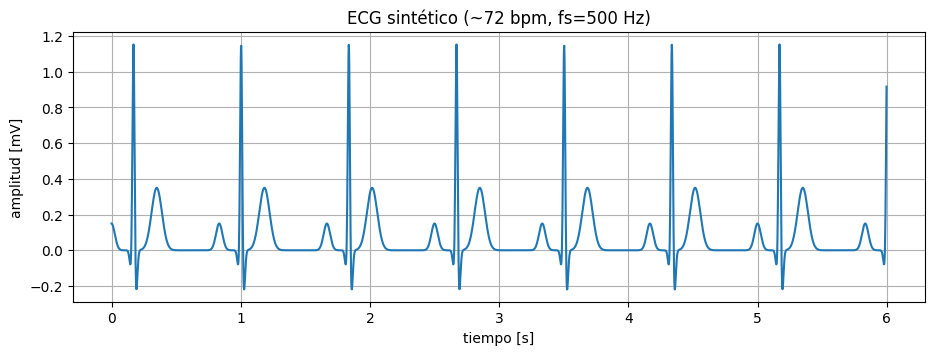

In [11]:
def gauss(t, mu, sigma, amp):
    """Gaussiana centrada en mu, ancho sigma, amplitud pico amp."""
    return amp * np.exp(-((t - mu) ** 2) / (2 * sigma ** 2))

def synthetic_ecg(duration_s, fs, hr_bpm=70):
    """ECG sintético: suma de gaussianas P, Q, R, S, T repetidas a hr_bpm bpm."""
    t = np.arange(0, duration_s, 1.0 / fs)
    rr = 60.0 / hr_bpm           # intervalo entre latidos en segundos
    ecg = np.zeros_like(t)
    waves = [
        # (offset_relativo_s, sigma_s, amplitud_mV)
        (0.00, 0.025,  0.15),    # P
        (0.15, 0.010, -0.10),    # Q
        (0.17, 0.008,  1.20),    # R
        (0.19, 0.010, -0.25),    # S
        (0.35, 0.040,  0.35),    # T
    ]
    n_beats = int(np.ceil(duration_s / rr)) + 1
    for k in range(n_beats):
        t0 = k * rr
        for off, sigma, amp in waves:
            ecg += gauss(t, t0 + off, sigma, amp)
    return t, ecg

fs = 500  # Hz
t, ecg = synthetic_ecg(duration_s=6.0, fs=fs, hr_bpm=72)

plt.plot(t, ecg)
plt.xlabel('tiempo [s]'); plt.ylabel('amplitud [mV]')
plt.title('ECG sintético (~72 bpm, fs=500 Hz)')
plt.show()

### Ejercicio 1.1
Generen un ECG de 10 segundos a **120 bpm** y otro a **50 bpm**.
Plotéenlos en dos subplots y observen cómo cambia el intervalo RR.


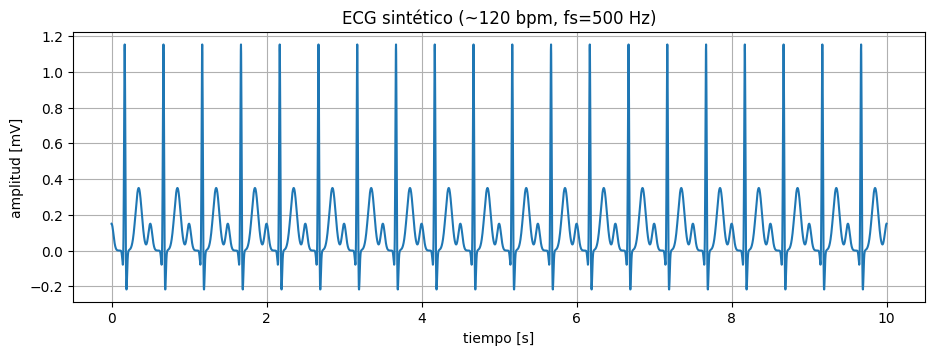

In [4]:
fs = 500  # Hz
t_120, ecg_120 = synthetic_ecg(duration_s=10.0, fs=fs, hr_bpm=120)

plt.plot(t_120, ecg_120)
plt.xlabel('tiempo [s]'); plt.ylabel('amplitud [mV]')
plt.title('ECG sintético (~120 bpm, fs=500 Hz)')
plt.show()


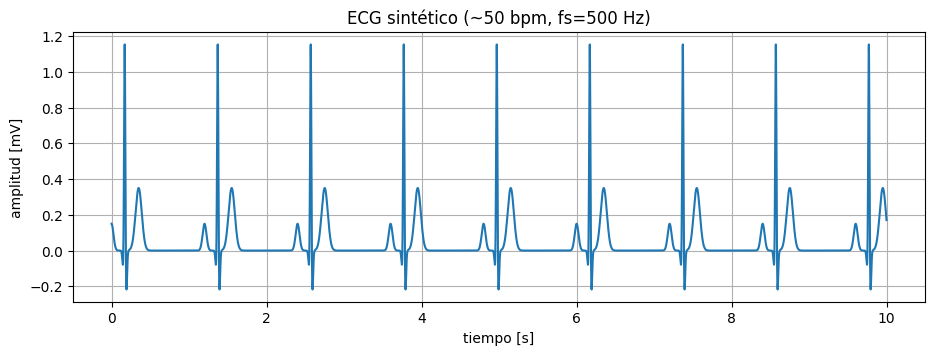

In [5]:
fs = 500  # Hz
t_50, ecg_50 = synthetic_ecg(duration_s=10.0, fs=fs, hr_bpm=50)

plt.plot(t_50, ecg_50)
plt.xlabel('tiempo [s]'); plt.ylabel('amplitud [mV]')
plt.title('ECG sintético (~50 bpm, fs=500 Hz)')
plt.show()


### Observación
Se observa que a mayor frecuencia cardíaca la distancia entre R-R disminuye, lo que significa que el ¨corazón¨ está latiendo más veces en menos tiempo. 

## 2. Dominio de la frecuencia: FFT

La **transformada rápida de Fourier (FFT)** nos da el espectro de la señal.
`scipy.fft.rfft` devuelve solo la mitad positiva del espectro (las frecuencias negativas son simétricas para señales reales, así que no aportan información nueva).

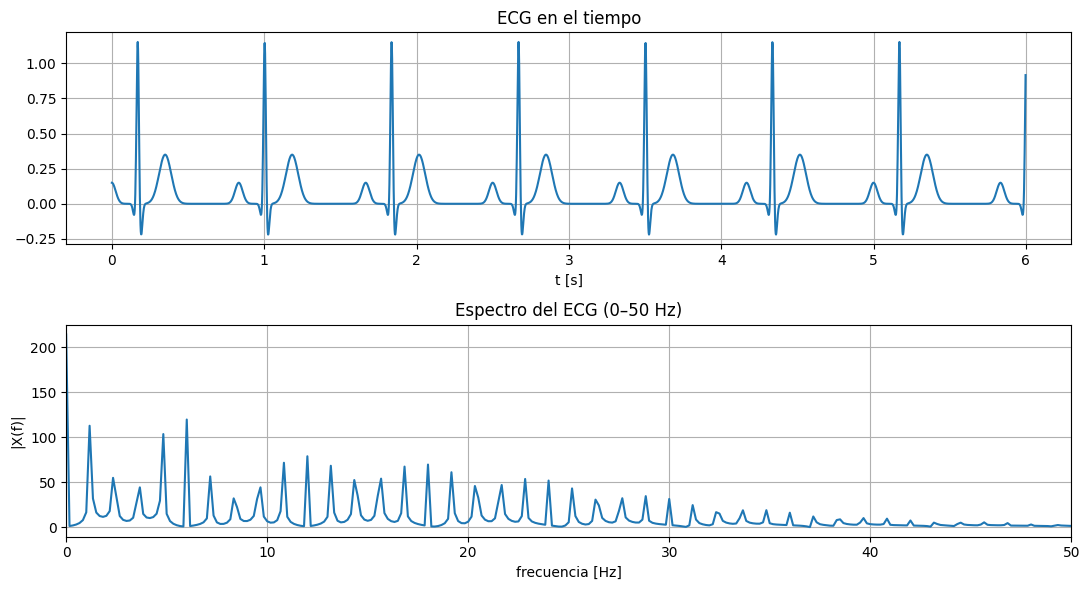

In [6]:
def plot_spectrum(x, fs, ax=None, fmax=None, title=None):
    X = np.abs(rfft(x))
    freqs = rfftfreq(len(x), 1.0 / fs)
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(freqs, X)
    if fmax is not None:
        ax.set_xlim(0, fmax)
    ax.set_xlabel('frecuencia [Hz]'); ax.set_ylabel('|X(f)|')
    if title:
        ax.set_title(title)
    return ax

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
axes[0].plot(t, ecg); axes[0].set_xlabel('t [s]'); axes[0].set_title('ECG en el tiempo')
plot_spectrum(ecg, fs, ax=axes[1], fmax=50, title='Espectro del ECG (0–50 Hz)')
plt.tight_layout(); plt.show()

Observen que la mayor parte de la energía está concentrada **por debajo de los 40 Hz** — eso es típico de un ECG normal.
La componente fundamental (alrededor de 1.2 Hz para 72 bpm) y sus harmónicos son los picos más notorios.

### Ejercicio 2.1
Generen una señal de 5 segundos que sea **suma de dos sinusoides** (por ejemplo 5 Hz y 12 Hz) más una pequeña componente continua.
Plotéenla en tiempo y en frecuencia. ¿En qué posiciones aparecen los picos del espectro?

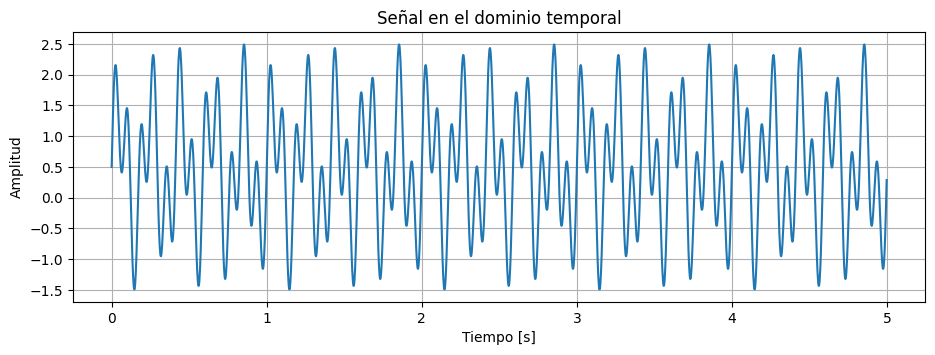

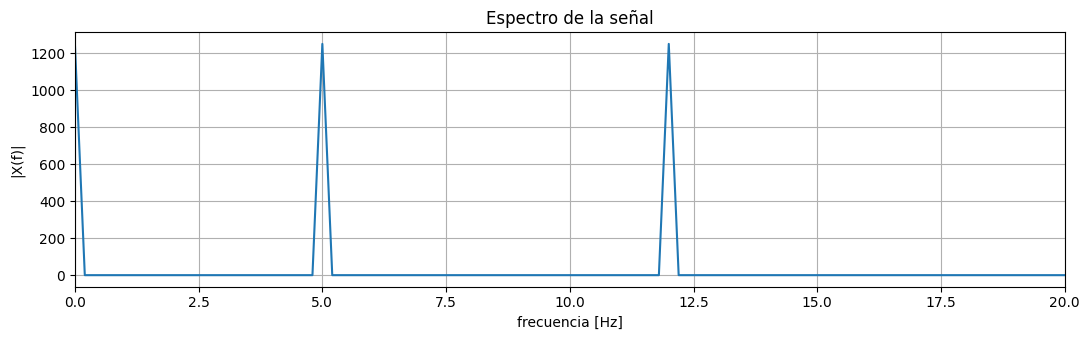

In [7]:
fs = 500  
t = np.arange(0, 5, 1/fs)

x = np.sin(2*np.pi*5*t) + np.sin(2*np.pi*12*t) + 0.5

plt.plot(t, x)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal en el dominio temporal')

plot_spectrum(x, fs, fmax=20, title='Espectro de la señal')

plt.tight_layout()
plt.show()


### Respuesta
Los picos se observar en 0.5, 5 y 12 Hz

## 3. Muestreo y aliasing

**Teorema de Nyquist:** para reconstruir sin pérdida una señal cuya frecuencia máxima es `f_max`, hay que muestrearla a **`fs ≥ 2·f_max`**.
Si `fs` es menor, las frecuencias altas se *doblan* sobre las bajas — eso es **aliasing**, y es irreversible.

Vamos a generar una sinusoide pura de **60 Hz** y muestrearla a tres frecuencias distintas para ver el fenómeno.

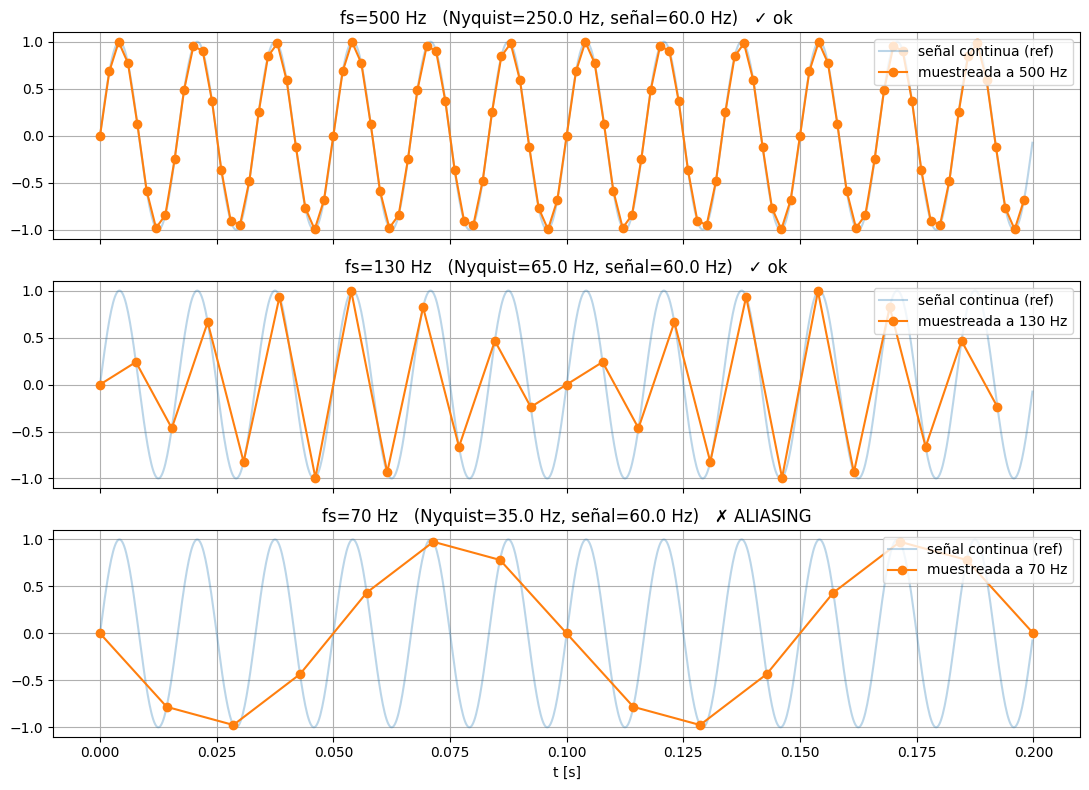

In [8]:
f_signal = 60.0   # Hz — frecuencia 'real' de la señal
duration = 0.2

# señal de referencia 'casi continua' (muestreada muy rápido)
fs_ref = 5000
t_ref = np.arange(0, duration, 1/fs_ref)
x_ref = np.sin(2 * np.pi * f_signal * t_ref)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, fs_low in zip(axes, [500, 130, 70]):
    t_low = np.arange(0, duration, 1/fs_low)
    x_low = np.sin(2 * np.pi * f_signal * t_low)
    ax.plot(t_ref, x_ref, alpha=0.3, label='señal continua (ref)')
    ax.plot(t_low, x_low, 'o-', label=f'muestreada a {fs_low} Hz')
    nyquist = fs_low / 2
    ok = '✓ ok' if nyquist >= f_signal else '✗ ALIASING'
    ax.set_title(f'fs={fs_low} Hz   (Nyquist={nyquist} Hz, señal={f_signal} Hz)   {ok}')
    ax.legend(loc='upper right')
axes[-1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

### Ejercicio 3.1
Un ECG tiene componentes útiles hasta unos **150 Hz**. ¿Cuál sería la frecuencia de muestreo mínima teórica? ¿Y la que recomendarías en la práctica clínica? Justificá brevemente en una celda de markdown.

Según el Teorema de Nyquist, la frecuencia de muestreo debe ser al menos de 300 Hz, dado que en el ECG las componentes útiles son de una fmax= 150 Hz. Sin embargo, en la práctica usaríamos 500 Hz o más, porque podriamos captar mejor los detalles de la señal.

## 4. Convolución 1D desde cero

La convolución de una señal `x` con un kernel `h` se define como:

$$y[n] = \sum_k h[k] \cdot x[n - k]$$

Vamos a implementarla a mano y compararla con `np.convolve`.

In [9]:
def conv_manual(x, h):
    """Convolución 1D 'válida' implementada a mano (didáctica, no optimizada)."""
    n = len(x); m = len(h)
    y = np.zeros(n - m + 1)
    for i in range(len(y)):
        y[i] = np.sum(x[i:i+m] * h[::-1])
    return y

x_test = np.array([0, 0, 1, 2, 3, 2, 1, 0, 0], dtype=float)
h_test = np.array([0.25, 0.5, 0.25])  # promedio ponderado de 3 muestras

y_manual = conv_manual(x_test, h_test)
y_numpy = np.convolve(x_test, h_test, mode='valid')

print('manual:', y_manual)
print('numpy: ', y_numpy)
print('iguales?', np.allclose(y_manual, y_numpy))

manual: [0.25 1.   2.   2.5  2.   1.   0.25]
numpy:  [0.25 1.   2.   2.5  2.   1.   0.25]
iguales? True


### Filtro media móvil aplicado al ECG

Un kernel del tipo `[1, 1, ..., 1] / N` actúa como un **filtro pasa-bajo simple** (media móvil): suaviza la señal promediando ventanas de N muestras.

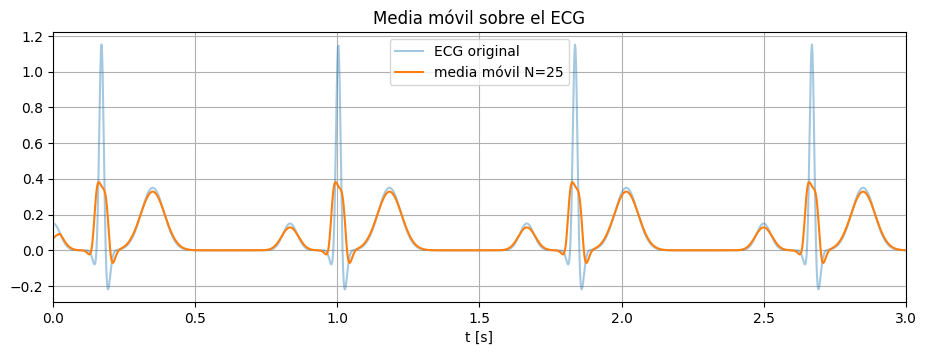

In [12]:
N = 25  # tamaño del kernel
kernel_ma = np.ones(N) / N

ecg_smooth = np.convolve(ecg, kernel_ma, mode='same')

plt.plot(t, ecg, alpha=0.4, label='ECG original')
plt.plot(t, ecg_smooth, label=f'media móvil N={N}')
plt.xlim(0, 3); plt.legend(); plt.xlabel('t [s]')
plt.title('Media móvil sobre el ECG')
plt.show()

### Ejercicio 4.1
Probá `N = 5`, `N = 25` y `N = 101`. ¿Qué le pasa a los picos QRS a medida que N crece? ¿Por qué?

*Pista: pensá qué fracción de un latido cubre cada kernel a fs=500 Hz.*

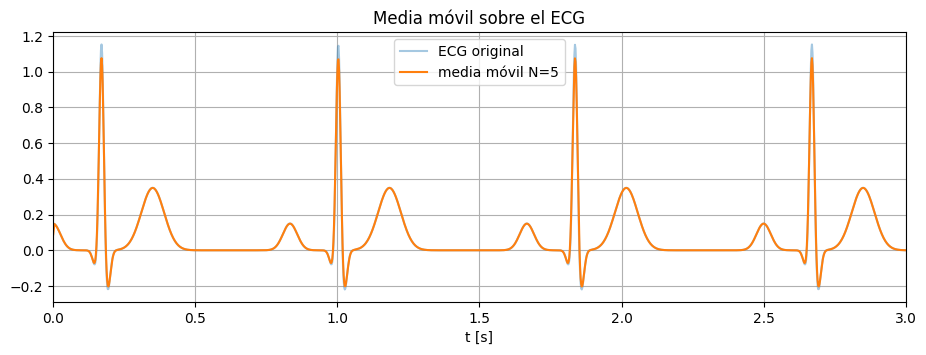

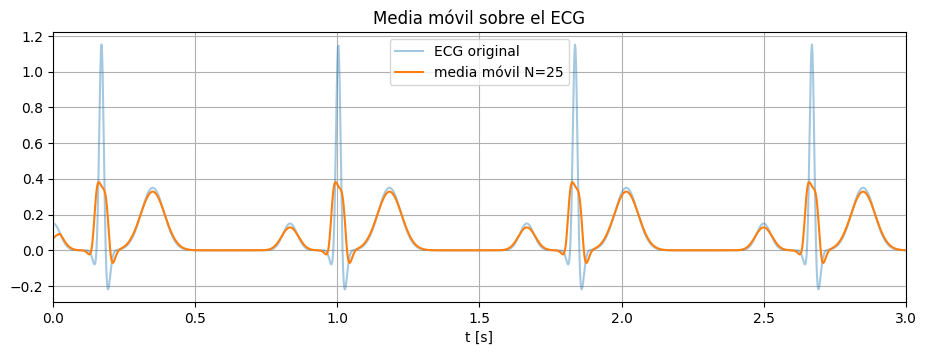

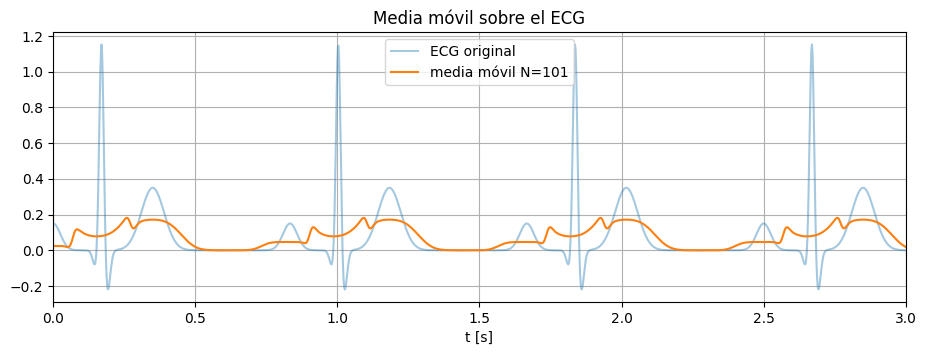

In [13]:
N_5 = 5  
N_25 = 25
N_101 = 101
kernel_ma_5 = np.ones(N_5) / N_5

ecg_smoothN_5 = np.convolve(ecg, kernel_ma_5, mode='same')

plt.plot(t, ecg, alpha=0.4, label='ECG original')
plt.plot(t, ecg_smoothN_5, label=f'media móvil N={N_5}')
plt.xlim(0, 3); plt.legend(); plt.xlabel('t [s]')
plt.title('Media móvil sobre el ECG')
plt.show()

kernel_ma_25 = np.ones(N_25) / N_25

ecg_smoothN_25 = np.convolve(ecg, kernel_ma_25, mode='same')

plt.plot(t, ecg, alpha=0.4, label='ECG original')
plt.plot(t, ecg_smoothN_25, label=f'media móvil N={N_25}')
plt.xlim(0, 3); plt.legend(); plt.xlabel('t [s]')
plt.title('Media móvil sobre el ECG')
plt.show()

kernel_ma_101 = np.ones(N_101) / N_101

ecg_smoothN_101 = np.convolve(ecg, kernel_ma_101, mode='same')

plt.plot(t, ecg, alpha=0.4, label='ECG original')
plt.plot(t, ecg_smoothN_101, label=f'media móvil N={N_101}')
plt.xlim(0, 3); plt.legend(); plt.xlabel('t [s]')
plt.title('Media móvil sobre el ECG')
plt.show()

#### Respuesta
A medida que aumenta N, el filtro deja pasar las frecuencias bajas y elimina cada vez más las frecuencias altas.
Los picos QRS son cambios muy rápidos de la señal, por lo que contienen componentes de frecuencia más altas que otras partes del ECG. Entonces con N = 5 el filtrado es suave y casi se conservan los QRS. Con N = 25 se eliminan más componentes altas y los QRS empiezan a verse más anchos y menos altos. Y por último, con N = 101: se eliminan muchas componentes altas y los QRS se aplanan.
Esto ocurre porque al aumentar N, la ventana de promedio se hace más grande y el filtro pasa-bajo se vuelve más fuerte (eliminando más componentes de alta frecuencia).

### Ejercicio 4.2 (conceptual)
Una **convolución 1D** de una CNN y un **filtro FIR** de DSP son matemáticamente la misma operación. ¿En qué se diferencian entonces? Respondé en una celda markdown — pensá en cómo se obtienen los coeficientes en cada caso.

#### Respuesta
Una convolución 1D de una CNN y un filtro FIR realizan matemáticamente la misma operación, ya que ambos aplican un kernel sobre una señal para generar una salida. La diferencia está en cómo se obtienen los coeficientes del kernel. En un filtro FIR, los diseñamos a mano según lo que queremos hacer, por ejemplo para eliminar ruido o dejar pasar ciertas frecuencias, mientras que en una CNN los coeficientes no se definen previamente sino que se aprenden durante el entrenamiento a partir de los datos para optimizar una tarea.

## 5. Filtros lineales

`scipy.signal` tiene utilidades para diseñar filtros IIR (Butterworth, Chebyshev, ...) y FIR.
Vamos a aplicar los **cuatro tipos básicos** a un ECG contaminado con tres tipos de ruido típicos.

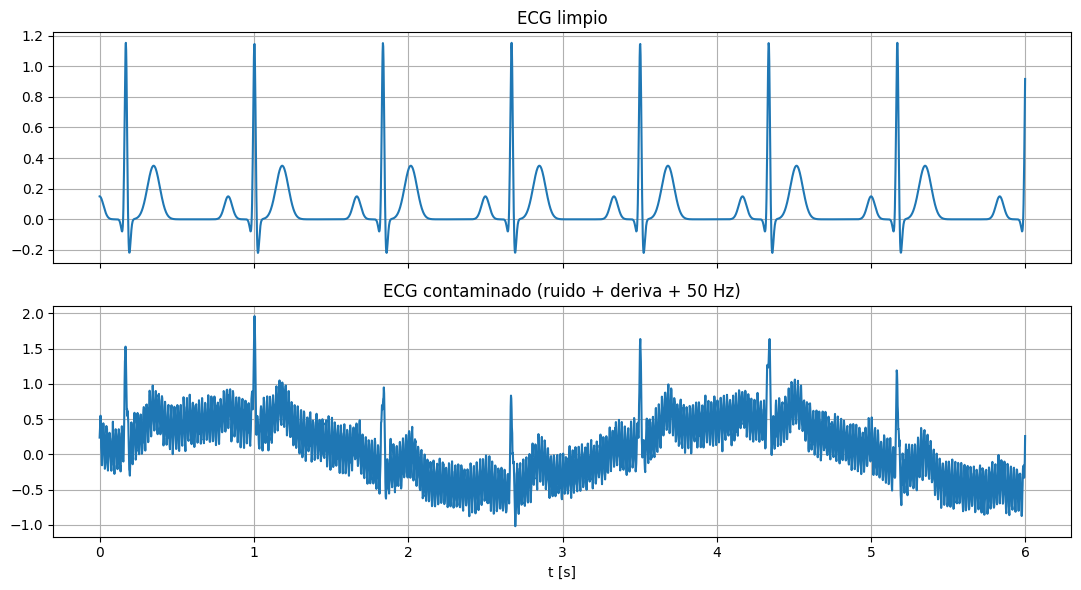

In [14]:
# ECG contaminado: ruido blanco + interferencia de 50 Hz + deriva por respiración
ruido  = 0.05 * np.random.randn(len(t))
deriva = 0.5  * np.sin(2 * np.pi * 0.3 * t)   # respiración a 0.3 Hz
linea  = 0.3  * np.sin(2 * np.pi * 50  * t)   # 50 Hz red eléctrica
ecg_sucio = ecg + ruido + deriva + linea

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(t, ecg);       axes[0].set_title('ECG limpio')
axes[1].plot(t, ecg_sucio); axes[1].set_title('ECG contaminado (ruido + deriva + 50 Hz)')
axes[1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

### Notch 50 Hz — sacamos la interferencia de red

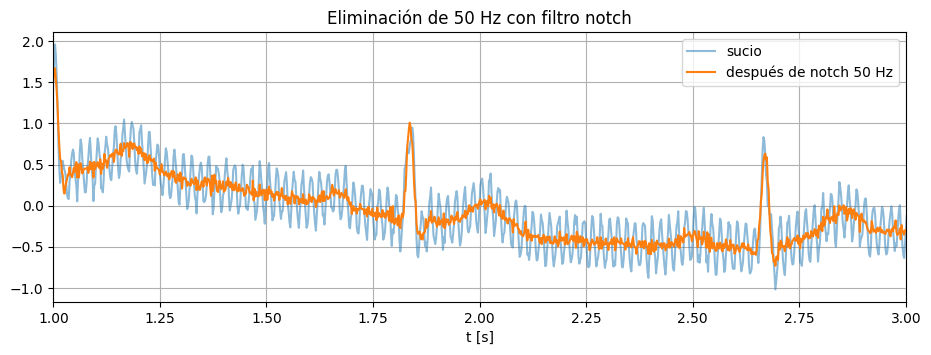

In [15]:
b, a = sps.iirnotch(w0=50, Q=30, fs=fs)
ecg_sin_50 = sps.filtfilt(b, a, ecg_sucio)

plt.plot(t, ecg_sucio,  alpha=0.5, label='sucio')
plt.plot(t, ecg_sin_50,           label='después de notch 50 Hz')
plt.xlim(1, 3); plt.legend(); plt.xlabel('t [s]')
plt.title('Eliminación de 50 Hz con filtro notch')
plt.show()

### Pasa-alto — sacamos la deriva lenta (respiración)

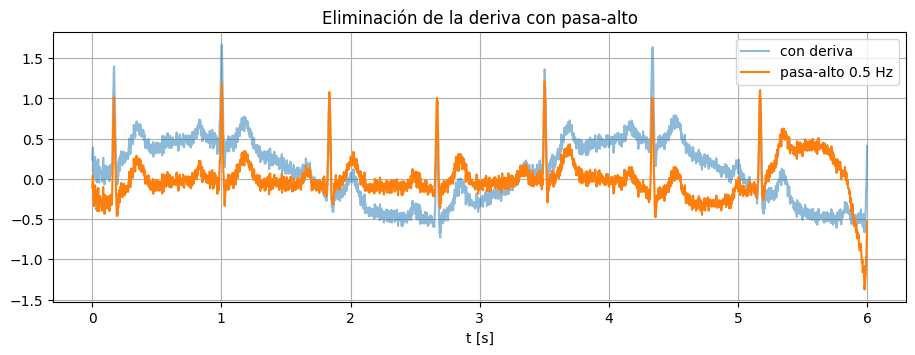

In [16]:
b, a = sps.butter(N=4, Wn=0.5, btype='highpass', fs=fs)
ecg_sin_deriva = sps.filtfilt(b, a, ecg_sin_50)

plt.plot(t, ecg_sin_50,       alpha=0.5, label='con deriva')
plt.plot(t, ecg_sin_deriva,             label='pasa-alto 0.5 Hz')
plt.legend(); plt.xlabel('t [s]')
plt.title('Eliminación de la deriva con pasa-alto')
plt.show()

### Pasa-bajo — sacamos el ruido de alta frecuencia

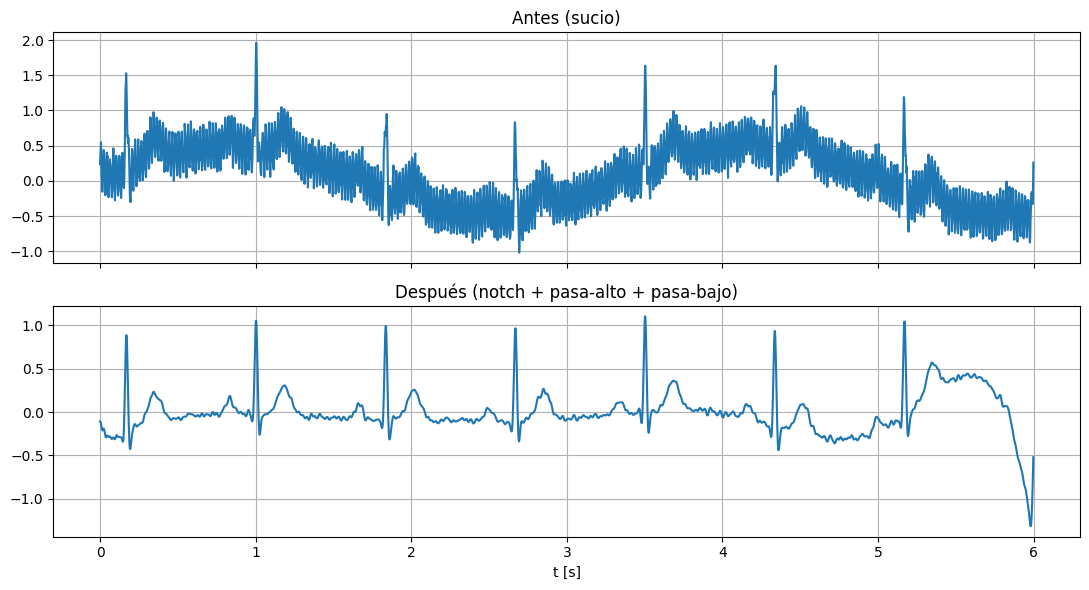

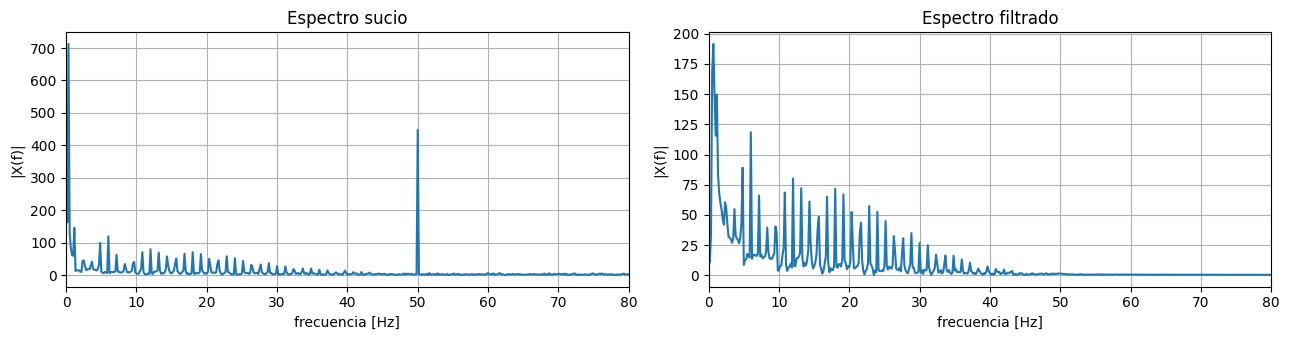

In [17]:
b, a = sps.butter(N=4, Wn=40, btype='lowpass', fs=fs)
ecg_limpio = sps.filtfilt(b, a, ecg_sin_deriva)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(t, ecg_sucio);  axes[0].set_title('Antes (sucio)')
axes[1].plot(t, ecg_limpio); axes[1].set_title('Después (notch + pasa-alto + pasa-bajo)')
axes[1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

# Espectros antes y después
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
plot_spectrum(ecg_sucio,  fs, ax=axes[0], fmax=80, title='Espectro sucio')
plot_spectrum(ecg_limpio, fs, ax=axes[1], fmax=80, title='Espectro filtrado')
plt.tight_layout(); plt.show()

### Pasa-banda — aislar una banda específica del EEG

Generamos un *EEG* sintético que es mezcla de varias bandas (delta, alfa, beta) más ruido, y aislamos la **banda alfa (8–12 Hz)** con un pasa-banda.

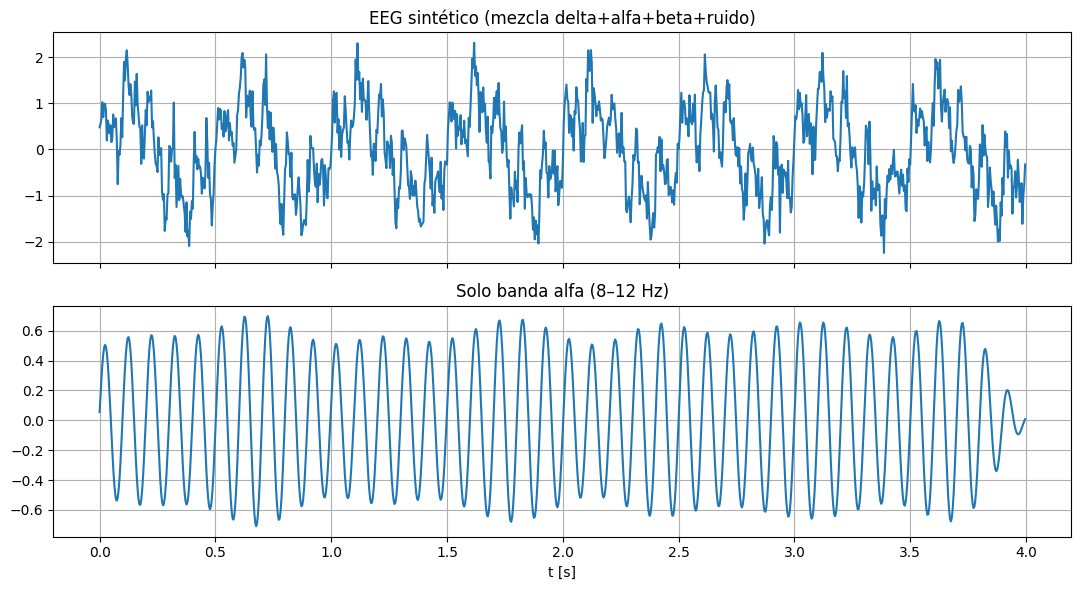

In [18]:
fs_eeg = 256
t_eeg = np.arange(0, 4, 1/fs_eeg)
eeg = (1.0 * np.sin(2*np.pi*2*t_eeg)   # delta
     + 0.6 * np.sin(2*np.pi*10*t_eeg)  # alfa
     + 0.4 * np.sin(2*np.pi*20*t_eeg)  # beta
     + 0.3 * np.random.randn(len(t_eeg)))

b, a = sps.butter(N=4, Wn=[8, 12], btype='bandpass', fs=fs_eeg)
eeg_alfa = sps.filtfilt(b, a, eeg)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(t_eeg, eeg);      axes[0].set_title('EEG sintético (mezcla delta+alfa+beta+ruido)')
axes[1].plot(t_eeg, eeg_alfa); axes[1].set_title('Solo banda alfa (8–12 Hz)')
axes[1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

### Ejercicio 5.1
Diseñá un filtro pasa-banda para la **banda beta (13–30 Hz)** del EEG y graficá el resultado junto al EEG original. ¿Qué notás en comparación con la banda alfa?

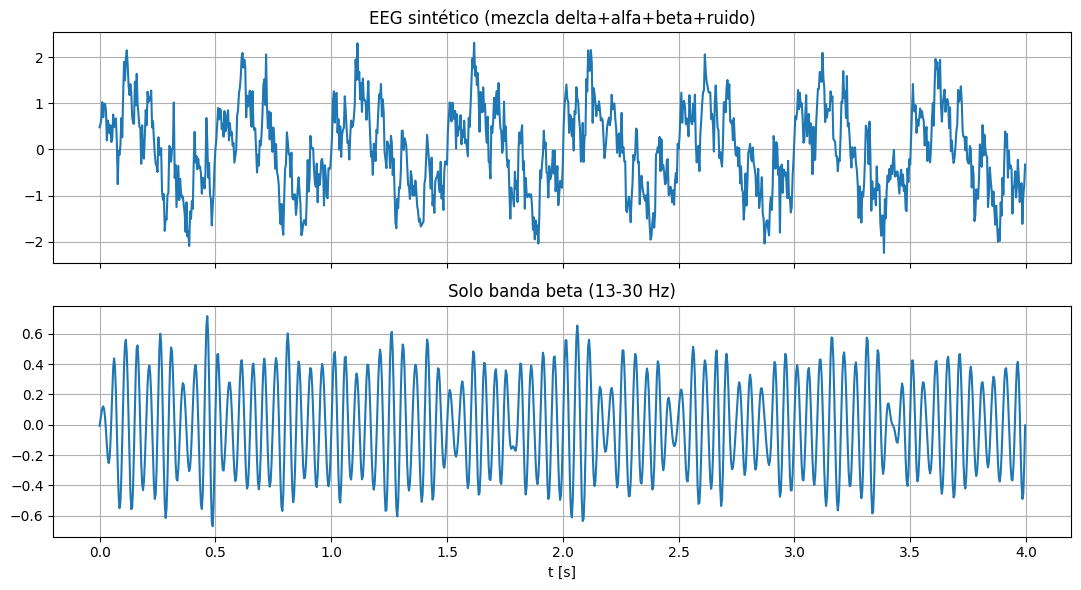

In [19]:
b, a = sps.butter(N=4, Wn=[13, 30], btype='bandpass', fs=fs_eeg)
eeg_beta = sps.filtfilt(b, a, eeg)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(t_eeg, eeg);      axes[0].set_title('EEG sintético (mezcla delta+alfa+beta+ruido)')
axes[1].plot(t_eeg, eeg_beta); axes[1].set_title('Solo banda beta (13-30 Hz)')
axes[1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()


#### Respuesta
Cuando aplicamos el filtro pasabanda para la banda beta (13–30 Hz) se observa una señal con oscilaciones más rápidas y de menor amplitud en comparación con la banda alfa. Mientras que la banda alfa (8–12 Hz) se ven ondas más lentas y suaves, la banda beta muestra más ciclos en el mismo intervalo de tiempo ya que contiene frecuencias más altas.

## 6. Ruido y SNR

**SNR** = potencia(señal) / potencia(ruido), generalmente expresada en **decibeles**:

$$\mathrm{SNR}_{dB} = 10 \cdot \log_{10}\left( \frac{P_\text{señal}}{P_\text{ruido}} \right)$$

Vamos a medir el SNR del ECG sucio y del ECG filtrado, usando como **referencia** la señal limpia original (algo que en datos reales no tenemos, pero acá sí porque la generamos nosotros).

In [20]:
def snr_db(senal_limpia, senal_observada):
    """SNR en dB tomando 'senal_limpia' como referencia y la diferencia como ruido."""
    ruido = senal_observada - senal_limpia
    p_senal = np.mean(senal_limpia ** 2)
    p_ruido = np.mean(ruido ** 2)
    return 10 * np.log10(p_senal / p_ruido)

print(f'SNR ECG sucio:    {snr_db(ecg, ecg_sucio):.2f} dB')
print(f'SNR ECG filtrado: {snr_db(ecg, ecg_limpio):.2f} dB')

SNR ECG sucio:    -7.25 dB
SNR ECG filtrado: -0.96 dB


### Ejercicio 6.1
Generá tres versiones del ECG agregando ruido blanco con desvíos `0.01`, `0.1` y `0.5`. Calculá el SNR de cada una respecto al ECG limpio y ploteálas. ¿A partir de qué nivel el ruido domina visualmente la señal?

SNR con desvío 0.01: 1.71 dB
SNR con desvío 0.1: 0.80 dB
SNR con desvío 0.5: -6.79 dB


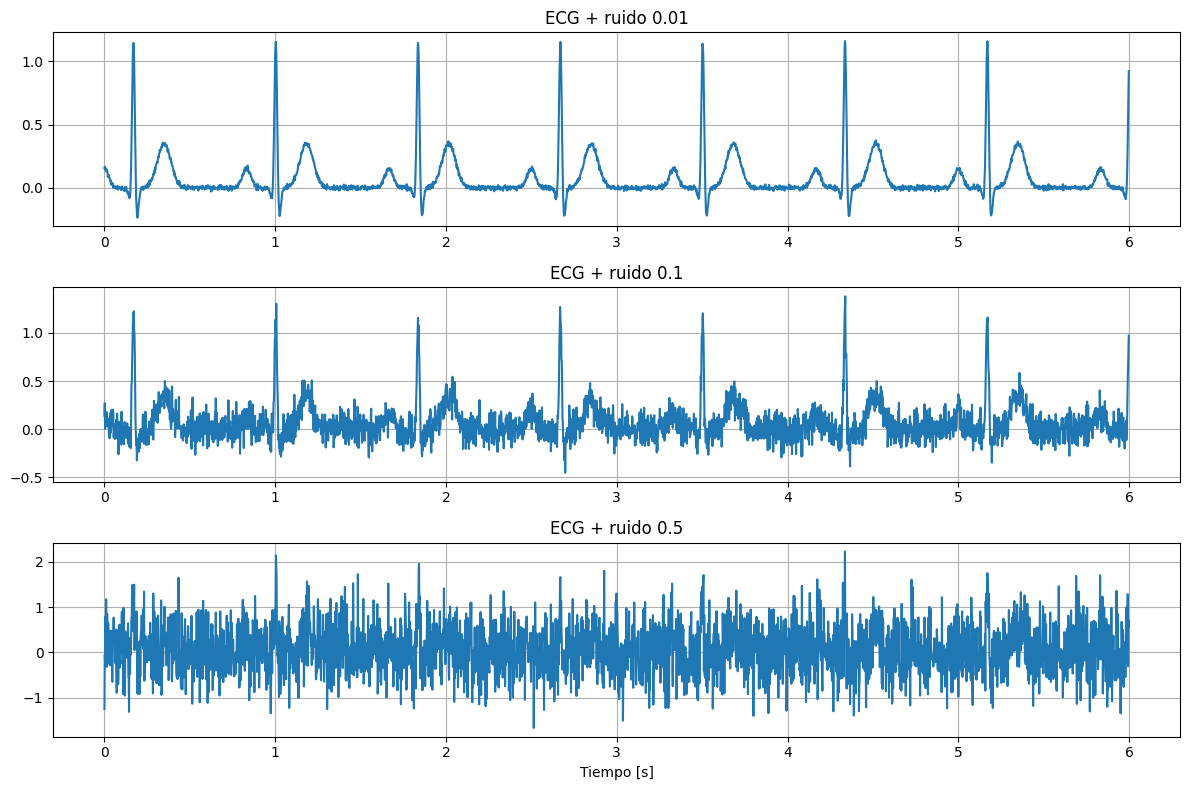

In [21]:
ruido1 = np.random.normal(0, 0.01, len(ecg))
ruido2 = np.random.normal(0, 0.1, len(ecg))
ruido3 = np.random.normal(0, 0.5, len(ecg))

ecg1 = ecg + ruido1
ecg2 = ecg + ruido2
ecg3 = ecg + ruido3

print(f'SNR con desvío 0.01: {snr_db(ecg_limpio, ecg1):.2f} dB')
print(f'SNR con desvío 0.1: {snr_db(ecg_limpio, ecg2):.2f} dB')
print(f'SNR con desvío 0.5: {snr_db(ecg_limpio, ecg3):.2f} dB')

plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(t, ecg1)
plt.title('ECG + ruido 0.01')

plt.subplot(3,1,2)
plt.plot(t, ecg2)
plt.title('ECG + ruido 0.1')

plt.subplot(3,1,3)
plt.plot(t, ecg3)
plt.title('ECG + ruido 0.5')
plt.xlabel('Tiempo [s]')

plt.tight_layout()
plt.show()

#### Respuesta
Si comparamos las tres señales, observamos que con desvío de 0.01, el ruido tiene un efecto mínimo y la forma del ECG se conserva. Con desvío de 0.1, el ruido se vuelve más notorio, aunque todavía podemos distinguir los complejos QRS y la estructura general de la señal. En cambio, con desvío de 0.5, el ruido empieza a dominar por sobre la señal.

## 7. Bonus: detección de picos QRS con *matched filter*

Un **matched filter** es la convolución entre la señal y una **plantilla** (template) de lo que queremos detectar.
Donde aparezca la plantilla, la convolución se hace grande — entonces buscando los picos de la salida, ubicamos las ocurrencias del patrón.

Idea: usamos un latido limpio aislado como plantilla y convolucionamos contra el ECG completo.

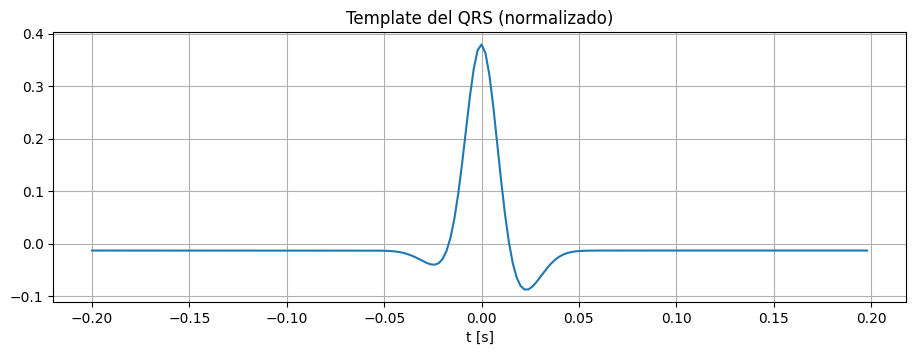

In [22]:
# Plantilla: un solo latido limpio centrado en t=0, ~0.4 s
t_template = np.arange(-0.2, 0.2, 1/fs)
template = (gauss(t_template,  0.00, 0.008,  1.20)
          + gauss(t_template, -0.02, 0.010, -0.10)
          + gauss(t_template,  0.02, 0.010, -0.25))
template = template - template.mean()
template = template / np.linalg.norm(template)

plt.plot(t_template, template)
plt.title('Template del QRS (normalizado)')
plt.xlabel('t [s]'); plt.show()

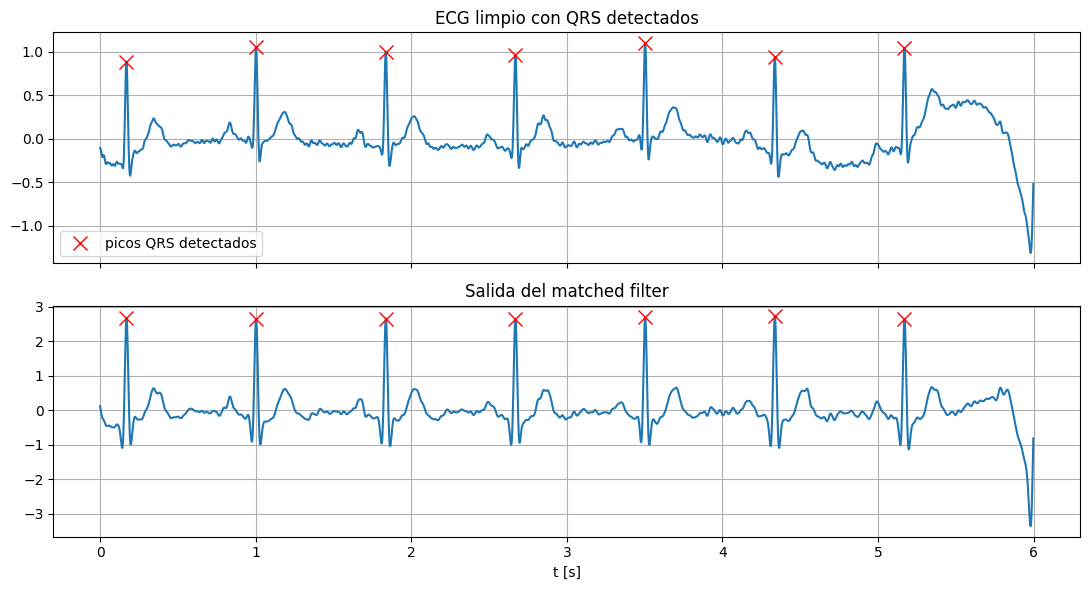

Frecuencia cardíaca estimada: 72.0 bpm (esperada: 72 bpm)


In [23]:
# Matched filter: convolución con la plantilla invertida en el tiempo
mf = np.convolve(ecg_limpio, template[::-1], mode='same')

# Picos: altura mínima y separación mínima (refractario fisiológico ~0.4 s)
peaks, _ = sps.find_peaks(mf, height=mf.max() * 0.5, distance=int(0.4 * fs))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(t, ecg_limpio)
axes[0].plot(t[peaks], ecg_limpio[peaks], 'rx', ms=10, label='picos QRS detectados')
axes[0].legend(); axes[0].set_title('ECG limpio con QRS detectados')
axes[1].plot(t, mf)
axes[1].plot(t[peaks], mf[peaks], 'rx', ms=10)
axes[1].set_title('Salida del matched filter')
axes[1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

# Frecuencia cardíaca estimada
rr_intervals = np.diff(t[peaks])
hr_est = 60.0 / np.mean(rr_intervals)
print(f'Frecuencia cardíaca estimada: {hr_est:.1f} bpm (esperada: 72 bpm)')

### Ejercicio 7.1
Aplicá el mismo matched filter sobre el **ECG sucio sin filtrar**. ¿Funciona igual de bien? ¿Qué pasa si la frecuencia cardíaca del registro es muy distinta a la del template?

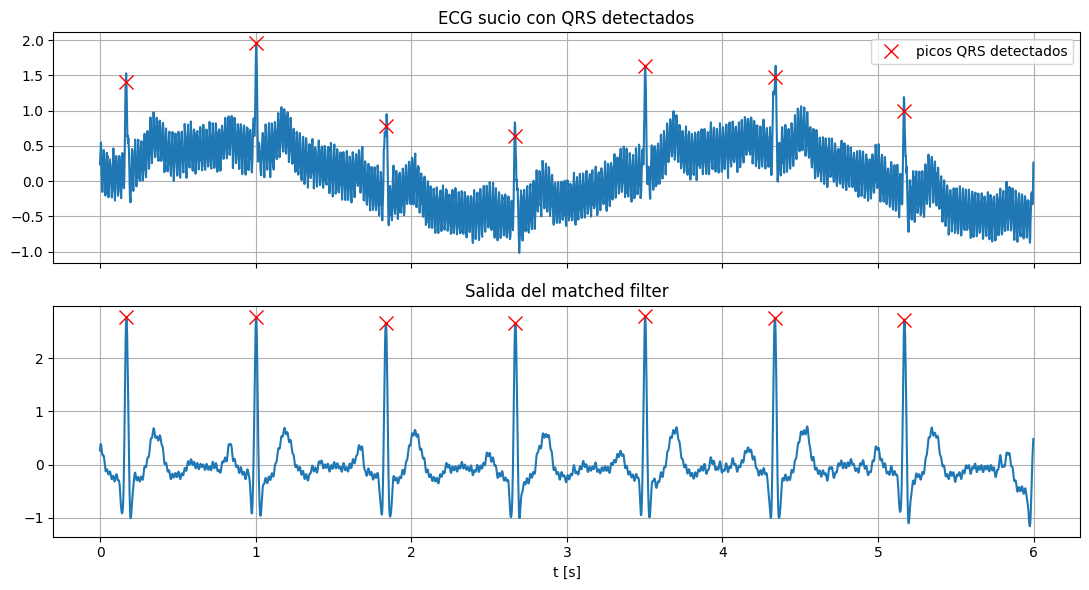

Frecuencia cardíaca estimada: 72.0 bpm (esperada: 72 bpm)


In [24]:
mf_sucio = np.convolve(ecg_sucio, template[::-1], mode='same')


peaks_sucio, _ = sps.find_peaks(mf_sucio, height=mf_sucio.max() * 0.5, distance=int(0.4 * fs))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(t, ecg_sucio)
axes[0].plot(t[peaks_sucio], ecg_sucio[peaks_sucio], 'rx', ms=10, label='picos QRS detectados')
axes[0].legend(); axes[0].set_title('ECG sucio con QRS detectados')
axes[1].plot(t, mf_sucio)
axes[1].plot(t[peaks_sucio], mf_sucio[peaks_sucio], 'rx', ms=10)
axes[1].set_title('Salida del matched filter')
axes[1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

# Frecuencia cardíaca estimada
rr_intervals = np.diff(t[peaks_sucio])
hr_est = 60.0 / np.mean(rr_intervals)
print(f'Frecuencia cardíaca estimada: {hr_est:.1f} bpm (esperada: 72 bpm)')

#### Respuesta

Al aplicar el matched filter sobre el ECG sucio sin filtrar, funciona patrcido que al del ECG limpio. Igualmente, en la salida aparecen más variaciones producidas por el ruido que ya teníamos en la entrada. 

Creemos que si la frecuencia cardíaca del ECG es muy distinta de la utilizada para construir el template, el desempeño también empeora porque el patrón temporal deja de coincidir correctamente con la señal real. El matched filter funciona buscando similitud con una forma específica (lo que llamamos template); si los latidos reales tienen distinta duración (frecuencia), la correlación disminuye y pueden perderse picos verdaderos o detectarse picos incorrectos.

## 8. Hacia lo generativo

Hasta acá analizamos señales. Ahora vamos a darle la vuelta: **fabricar señales** desde cero.

Lo vamos a hacer de dos formas — sin redes neuronales todavía —, y los dos enfoques aparecen como base de los modelos generativos modernos:

1. **Generación paramétrica:** una función con parámetros que controlamos a mano.
2. **Generación en el dominio de la frecuencia:** elegimos un *perfil espectral* y obtenemos ruido con esa forma.

Después conectamos las dos ideas con la práctica más usada al entrenar modelos sobre señales: **data augmentation**.

### 8.1 Generador paramétrico — un dataset sintético de ECGs

Nuestro `synthetic_ecg` **ya es un generador**. Si lo envolvemos en un loop que samplea parámetros aleatorios (frecuencia cardíaca, amplitud, ruido), conseguimos un *dataset* sintético tan grande como queramos.

Esto es la versión más simple de lo que hace un modelo generativo: tomar muestras de una distribución sobre señales.

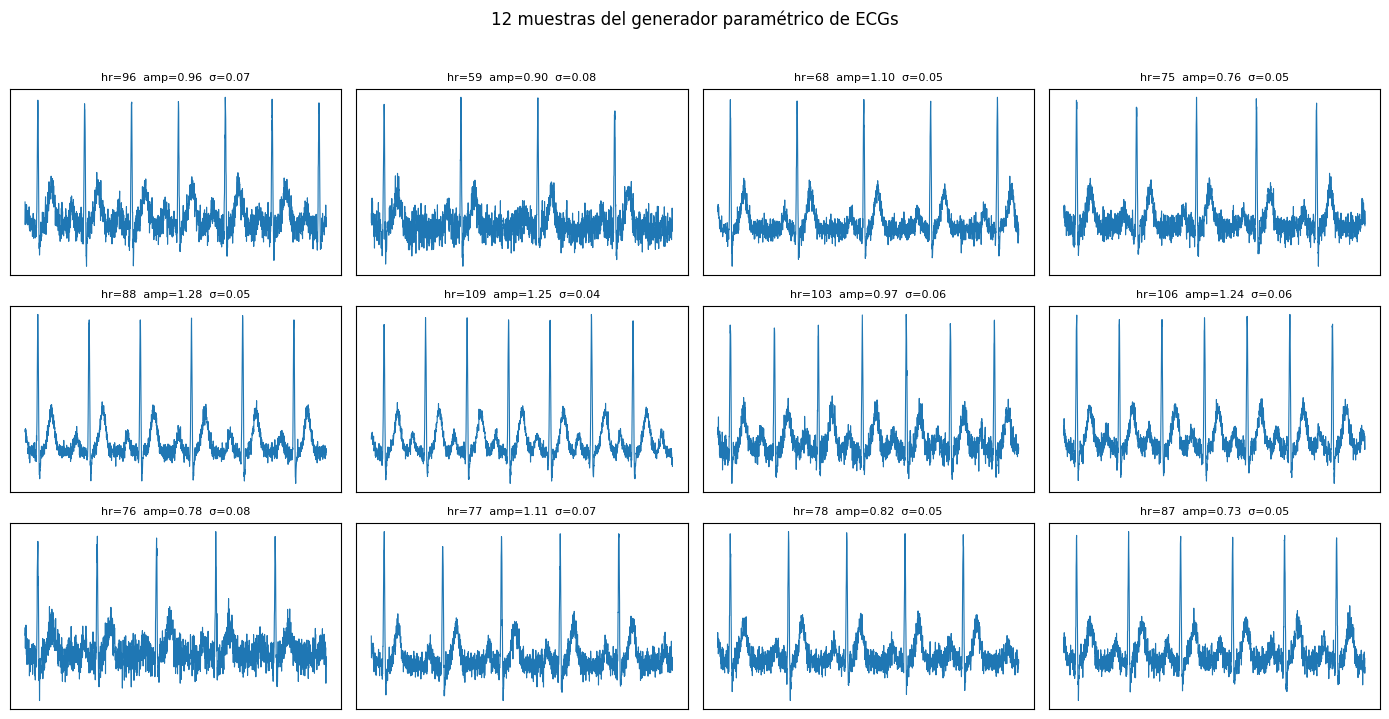

In [25]:
def random_synthetic_ecg(rng, duration_s=4.0, fs=500):
    """Un ECG sintético con parámetros aleatorios."""
    hr     = rng.uniform(50, 110)            # bpm
    amp    = rng.uniform(0.7, 1.3)           # escala global
    sigma  = rng.uniform(0.02, 0.08)         # nivel de ruido
    t, ecg = synthetic_ecg(duration_s, fs, hr_bpm=hr)
    ecg = amp * ecg + sigma * rng.standard_normal(len(ecg))
    return t, ecg, {'hr': hr, 'amp': amp, 'sigma': sigma}

rng = np.random.default_rng(42)
fig, axes = plt.subplots(3, 4, figsize=(14, 7))
for ax in axes.flat:
    ti, xi, params = random_synthetic_ecg(rng)
    ax.plot(ti, xi, lw=0.8)
    ax.set_title(f"hr={params['hr']:.0f}  amp={params['amp']:.2f}  σ={params['sigma']:.2f}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('12 muestras del generador paramétrico de ECGs', y=1.02)
plt.tight_layout(); plt.show()

**Observación importante:** este generador es muy controlable pero **no captura toda la variabilidad fisiológica real** (arritmias, patologías, variaciones individuales). Las próximas clases del módulo van a abordar generadores **aprendidos desde datos** que sí pueden capturar esa variabilidad — GANs, VAEs y modelos de difusión 1D.

### 8.2 Generador espectral — ruido con la forma que queramos

Receta:

1. Definir un **perfil de magnitud** deseado `|X(f)|` en el dominio de la frecuencia.
2. Sortear **fases aleatorias** uniformes para cada frecuencia.
3. Aplicar **FFT inversa** para volver al dominio del tiempo.

Cambiando solamente la forma del espectro pasamos de **ruido blanco** (energía uniforme) a **ruido rosa** (1/√f, típico de muchos sistemas biológicos) o a algo con el perfil característico de un ECG. Es la idea base detrás de generadores frecuenciales clásicos.

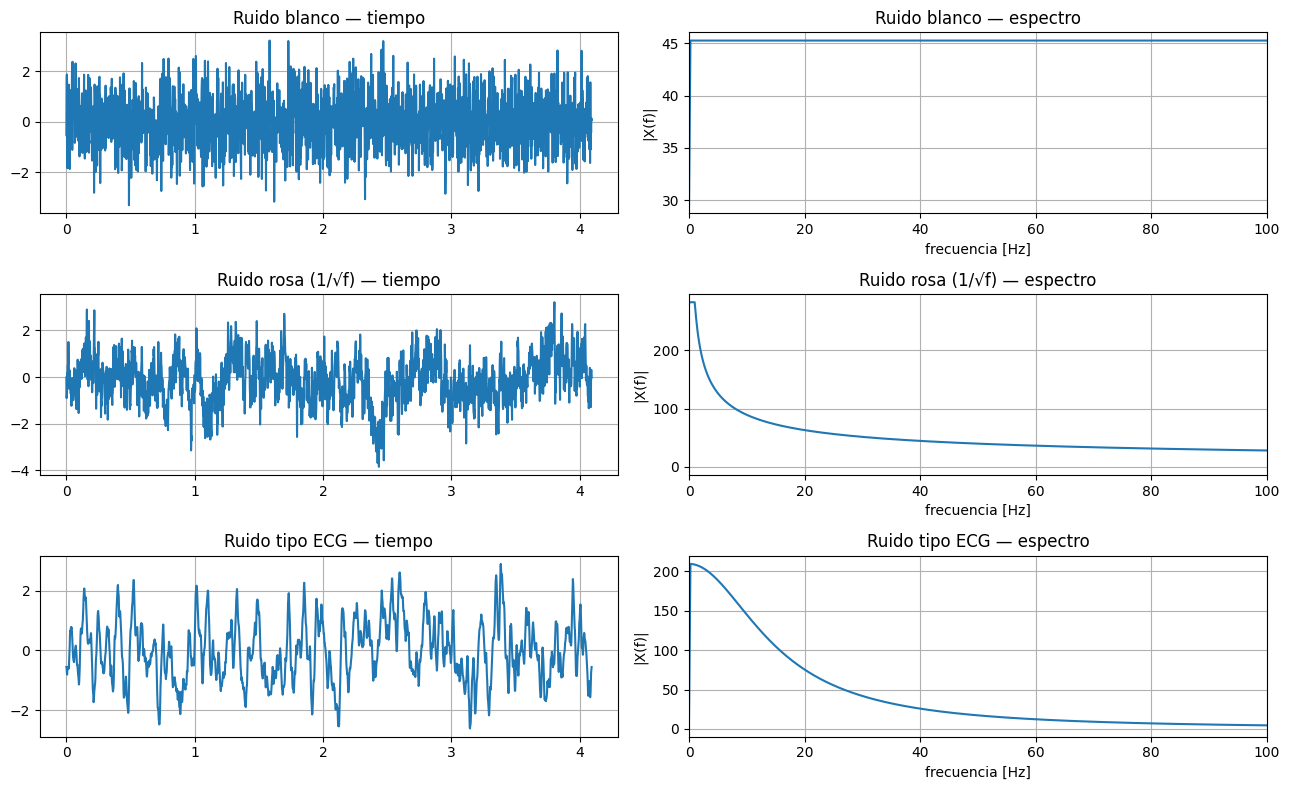

In [26]:
def shaped_noise(n, fs, shape_fn, seed=None):
    """Ruido de largo n a frecuencia fs con perfil espectral shape_fn(f)."""
    rng = np.random.default_rng(seed)
    freqs = rfftfreq(n, 1.0 / fs)
    mag = shape_fn(freqs)
    phase = np.exp(1j * 2 * np.pi * rng.random(len(freqs)))
    X = mag * phase
    x = np.fft.irfft(X, n=n)
    return x / (np.std(x) + 1e-12)

n = 2048; fs_n = 500
shapes = {
    'blanco':      lambda f: np.ones_like(f),
    'rosa (1/√f)': lambda f: 1.0 / np.sqrt(np.maximum(f, 1)),
    'tipo ECG':    lambda f: 1.0 / (1 + (f / 15) ** 2),
}

fig, axes = plt.subplots(len(shapes), 2, figsize=(13, 8))
tn = np.arange(n) / fs_n
for row, (name, shape_fn) in enumerate(shapes.items()):
    x = shaped_noise(n, fs_n, shape_fn, seed=row)
    axes[row, 0].plot(tn, x); axes[row, 0].set_title(f'Ruido {name} — tiempo')
    plot_spectrum(x, fs_n, ax=axes[row, 1], fmax=100, title=f'Ruido {name} — espectro')
plt.tight_layout(); plt.show()

### Ejercicio 8.1
Diseñá un `shape_fn` que genere **ruido de tipo EEG**: con la mayor parte de la energía concentrada en la banda 1–40 Hz y muy poca por encima. Verificá visualmente el resultado en el espectro.

*Pista:* podés usar el producto de un pasa-banda suave (por ejemplo dos sigmoides) o un rolloff exponencial.

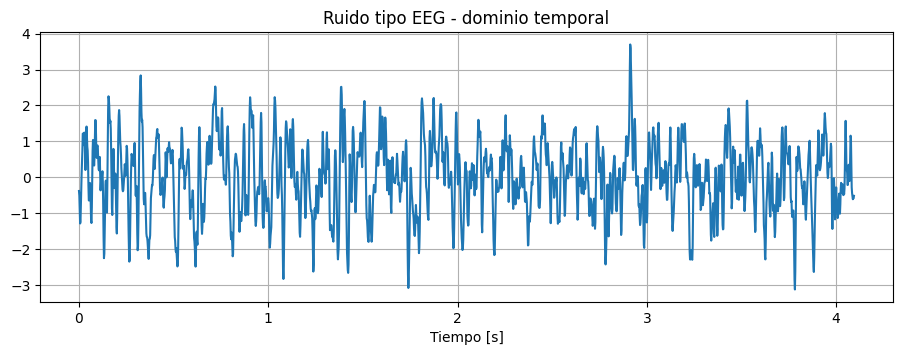

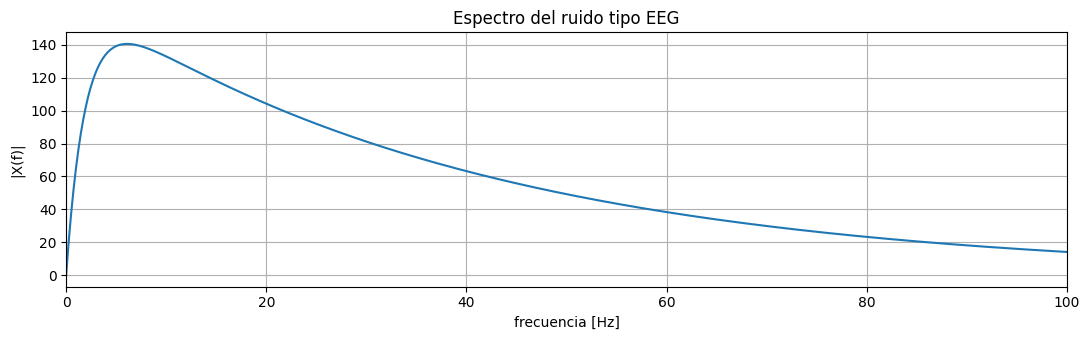

In [27]:
n = 2048
fs_n = 500

def eeg_shape(f):
    return (1 - np.exp(-f/2)) * np.exp(-f/40)

x_eeg = shaped_noise(n, fs_n, eeg_shape, seed=42)

tn = np.arange(n)/fs_n


plt.plot(tn, x_eeg)
plt.title('Ruido tipo EEG - dominio temporal')
plt.xlabel('Tiempo [s]')


plot_spectrum(x_eeg, fs_n, fmax=100,
              title='Espectro del ruido tipo EEG')

plt.tight_layout()
plt.show()


### 8.3 Data augmentation — el uso más práctico de la generación

Cuando entrenamos modelos sobre señales biomédicas casi nunca tenemos suficientes datos. La salida pragmática es **aumentar** el dataset combinando transformaciones que preserven la *etiqueta* (un latido sigue siendo un latido) pero introduzcan variabilidad.

Algunas transformaciones típicas:

- **Ruido aditivo:** simular distintos SNRs.
- **Escalado de amplitud:** simular distintos contactos y pacientes.
- **Time-stretch:** comprimir o estirar el eje temporal (simula cambios de frecuencia cardíaca).
- **Deriva de línea de base:** sumar una sinusoide lenta.
- **Electrode pop:** introducir un escalón breve para simular un artefacto.

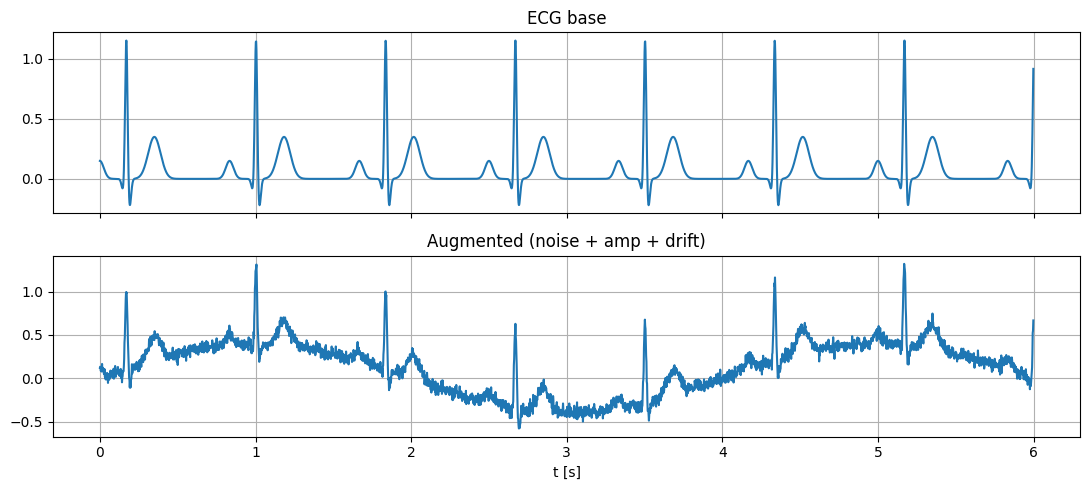

In [28]:
def add_noise(ecg, sigma, rng):
    return ecg + sigma * rng.standard_normal(len(ecg))

def amplitude_scale(ecg, factor):
    return ecg * factor

def add_baseline_drift(t, ecg, drift_hz, drift_amp):
    return ecg + drift_amp * np.sin(2 * np.pi * drift_hz * t)

# Ejemplo: una versión aumentada del ECG base
rng = np.random.default_rng(7)
ecg_aug = add_noise(ecg, 0.05, rng)
ecg_aug = amplitude_scale(ecg_aug, 0.8)
ecg_aug = add_baseline_drift(t, ecg_aug, drift_hz=0.25, drift_amp=0.4)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(t, ecg);     axes[0].set_title('ECG base')
axes[1].plot(t, ecg_aug); axes[1].set_title('Augmented (noise + amp + drift)')
axes[1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

### Ejercicio 8.2
Implementá una función `time_stretch(t, ecg, factor)` que estire o comprima la señal en el tiempo (por ejemplo `factor=1.2` la hace 20% más lenta — simulando una frecuencia cardíaca menor).

Después armá un pipeline `augment(t, ecg, rng)` que aplique las cuatro transformaciones con probabilidades y magnitudes aleatorias. Plotéa **6 versiones aumentadas** del mismo ECG en un grid.

*Pista para `time_stretch`:* usá `np.interp` sobre un nuevo eje de tiempo.

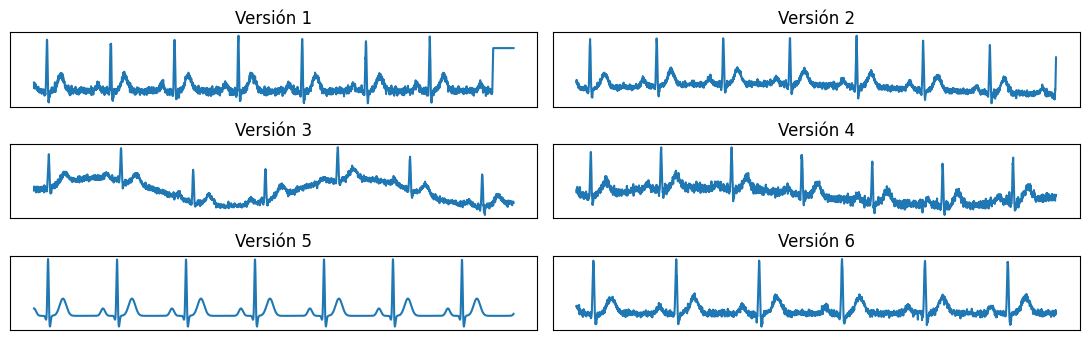

In [29]:

def time_stretch(t, ecg, factor):
    # Nuevo eje temporal escalado
    t_new = t / factor
    ecg_stretch = np.interp(t, t_new, ecg)
    return ecg_stretch


# Pipeline de aumento de datos
def augment(t, ecg, rng):
    ecg_aug = ecg.copy()

    if rng.random() < 0.8:
        sigma = rng.uniform(0.01,0.1)
        ecg_aug = add_noise(ecg_aug, sigma, rng)

    if rng.random() < 0.8:
        factor_amp = rng.uniform(0.7,1.3)
        ecg_aug = amplitude_scale(ecg_aug, factor_amp)

    if rng.random() < 0.8:
        drift_hz = rng.uniform(0.1,0.5)
        drift_amp = rng.uniform(0.1,0.4)
        ecg_aug = add_baseline_drift(t, ecg_aug, drift_hz, drift_amp)

    if rng.random() < 0.8:
        factor_time = rng.uniform(0.8,1.2)
        ecg_aug = time_stretch(t, ecg_aug, factor_time)

    return ecg_aug


rng = np.random.default_rng(42)


for i in range(6):
    ecg_aug = augment(t, ecg, rng)
    plt.subplot(3,2,i+1)
    plt.plot(t, ecg_aug)
    plt.title(f'Versión {i+1}')
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

### Reflexión

Lo que armaron en esta sección **ya son generadores**, aunque no haya redes neuronales todavía:

- El **paramétrico** está totalmente controlado pero limitado por las reglas que escribimos.
- El **espectral** controla la *forma global* pero no la *estructura semántica* (no produce QRS, solo ruido con cierta pinta).
- El **augmenter** parte de datos reales y los varía — es el puente más directo entre lo clásico y lo aprendido.

**A dónde vamos:** las próximas clases reemplazan *"elegir las reglas a mano"* por *"aprender el generador desde datos"*. Es lo que para imágenes hacen GANs, VAEs y modelos de difusión — y se traslada casi tal cual al dominio 1D.

## 9. Entrenamos un modelo generativo: VAE 1D sobre ECGs

Hasta acá los "generadores" eran reglas que escribimos a mano. Ahora vamos a **entrenar una red neuronal** para que aprenda a generar señales similares a nuestro dataset sintético.

Elegimos un **Variational Autoencoder (VAE)** porque:

- Es el modelo generativo más simple de entrenar.
- Tiene un **espacio latente** que podemos visualizar e interpolar.
- Las redes convolucionales 1D que usamos son **idénticas en concepto** a las CNNs 2D que vieron para imágenes.

Pipeline: dataset sintético → VAE 1D → reconstrucciones → sampling → interpolación.

### 9.1 Dataset — segmentos de ECG centrados en el QRS

Construimos un dataset de **2000 segmentos** de 256 muestras (~1 s a fs=250 Hz), cada uno centrado en un pico R de un ECG sintético con frecuencia cardíaca aleatoria. Centrar facilita la tarea del VAE — el modelo no necesita aprender invariancia de fase, solo la forma del latido y su contexto.

In [30]:
%pip install torch


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


device: cpu
train: (1800, 256)  val: (200, 256)


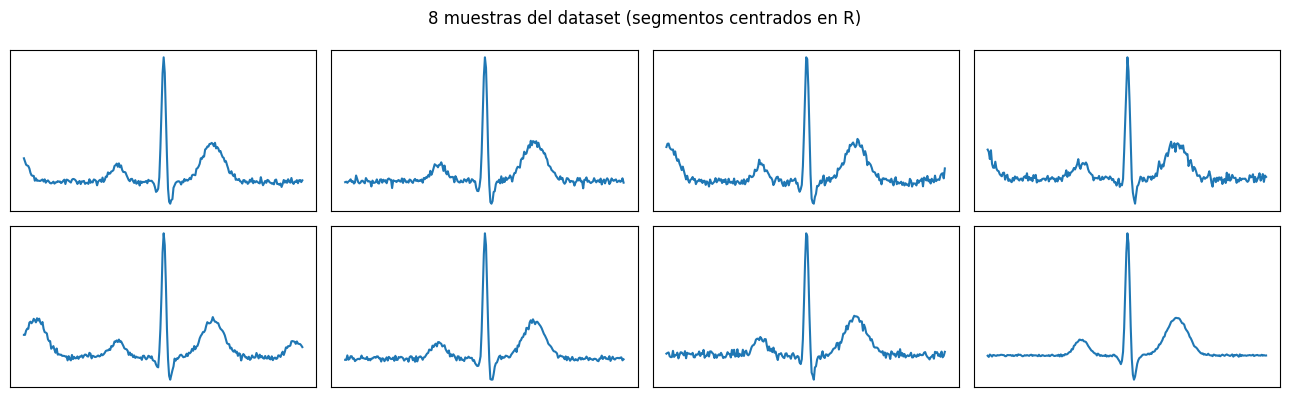

In [31]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

SIGNAL_LEN = 256
FS_GEN = 250

def make_ecg_dataset(n_samples, signal_len=SIGNAL_LEN, fs=FS_GEN, seed=0):
    """Dataset de segmentos de ECG centrados en un pico R."""
    rng = np.random.default_rng(seed)
    duration_long = 4.0
    half = signal_len // 2
    X = np.zeros((n_samples, signal_len), dtype=np.float32)
    for i in range(n_samples):
        hr = rng.uniform(50, 100)
        sigma = rng.uniform(0.005, 0.04)
        _, ecg_i = synthetic_ecg(duration_long, fs, hr_bpm=hr)
        # picos R esperados (en segundos)
        rr = 60.0 / hr
        r_times = 0.17 + rr * np.arange(int(duration_long / rr))
        # elegimos el R más cercano al centro
        chosen = r_times[np.argmin(np.abs(r_times - duration_long / 2))]
        center = int(chosen * fs)
        start = center - half
        if start < 0 or start + signal_len > len(ecg_i):
            start = max(0, min(len(ecg_i) - signal_len, start))
        seg = ecg_i[start:start + signal_len].copy()
        seg = seg + sigma * rng.standard_normal(signal_len)
        seg = (seg - seg.mean()) / (seg.std() + 1e-6)
        X[i] = seg
    return X

X = make_ecg_dataset(2000)
X_train, X_val = X[:1800], X[1800:]
print('train:', X_train.shape, ' val:', X_val.shape)

fig, axes = plt.subplots(2, 4, figsize=(13, 4))
for ax, x in zip(axes.flat, X_train[:8]):
    ax.plot(x); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('8 muestras del dataset (segmentos centrados en R)')
plt.tight_layout(); plt.show()

### 9.2 La arquitectura del VAE 1D

**Encoder:** tres `Conv1d` con stride=2 que reducen 256 → 128 → 64 → 32 muestras, y al final dos cabezales lineales que producen la media y log-varianza del *posterior* `q(z|x)`.

**Decoder:** una capa lineal expande el latente al tamaño del encoder y tres `ConvTranspose1d` reconstruyen 32 → 64 → 128 → 256.

**Trick de reparametrización:** muestreamos `z = μ + σ·ε`, con `ε ~ N(0, I)`, para que el sampling sea diferenciable.

**Pérdida:** error de reconstrucción (MSE) + divergencia KL contra el prior `N(0, I)`, ponderada por `β`.

In [32]:
class ECGVAE(nn.Module):
    def __init__(self, signal_len=SIGNAL_LEN, latent_dim=8):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3),   # 256 -> 128
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),  # 128 -> 64
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),  # 64 -> 32
            nn.ReLU(),
            nn.Flatten(),
        )
        flat = 64 * (signal_len // 8)
        self.fc_mu     = nn.Linear(flat, latent_dim)
        self.fc_logvar = nn.Linear(flat, latent_dim)
        self.fc_dec    = nn.Linear(latent_dim, flat)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, signal_len // 8)),
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),  # 32 -> 64
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2, padding=1),  # 64 -> 128
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1, kernel_size=4, stride=2, padding=1),   # 128 -> 256
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        return self.decoder(self.fc_dec(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar

vae = ECGVAE(latent_dim=8).to(device)
n_params = sum(p.numel() for p in vae.parameters())
print(f'VAE creado — {n_params:,} parámetros')

VAE creado — 74,593 parámetros


### 9.3 Entrenamiento

Entrenamos ~40 epochs con Adam y `β=0.5`. En CPU corre en menos de un minuto.

epoch   0  train   154.12  val    43.17
epoch   5  train    17.92  val    19.06
epoch  10  train    14.27  val    14.16
epoch  15  train    13.10  val    13.45
epoch  20  train    11.96  val    12.07
epoch  25  train    11.34  val    11.51
epoch  30  train    10.83  val    11.06
epoch  35  train    10.36  val    10.55
epoch  39  train     9.88  val    10.11


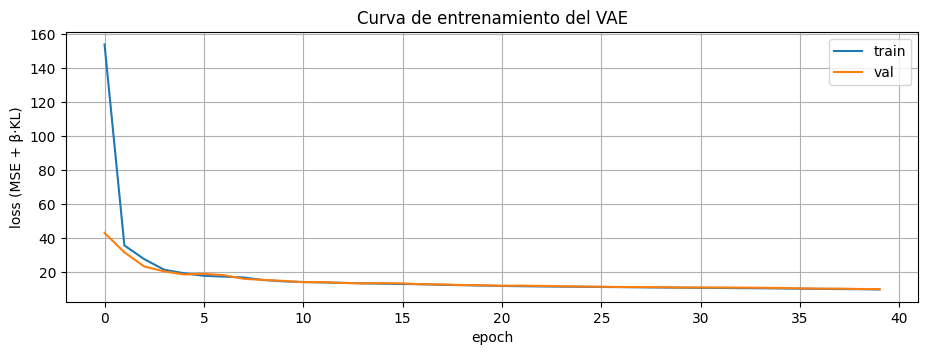

In [33]:
def vae_loss(recon, x, mu, logvar, beta=0.5):
    recon_loss = ((recon - x) ** 2).sum(dim=(1, 2)).mean()
    kl = -0.5 * (1 + logvar - mu ** 2 - logvar.exp()).sum(dim=1).mean()
    return recon_loss + beta * kl, recon_loss.item(), kl.item()

def to_loader(X, batch_size, shuffle):
    t = torch.from_numpy(X).float()
    return DataLoader(TensorDataset(t), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, batch_size=64, shuffle=True)
val_loader   = to_loader(X_val,   batch_size=64, shuffle=False)

opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
n_epochs = 40
history = {'train': [], 'val': []}

for epoch in range(n_epochs):
    vae.train(); total = 0; nseen = 0
    for (xb,) in train_loader:
        xb = xb.to(device).unsqueeze(1)
        recon, mu, logvar = vae(xb)
        loss, _, _ = vae_loss(recon, xb, mu, logvar)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * xb.size(0); nseen += xb.size(0)
    train_loss = total / nseen

    vae.eval(); total = 0; nseen = 0
    with torch.no_grad():
        for (xb,) in val_loader:
            xb = xb.to(device).unsqueeze(1)
            recon, mu, logvar = vae(xb)
            loss, _, _ = vae_loss(recon, xb, mu, logvar)
            total += loss.item() * xb.size(0); nseen += xb.size(0)
    val_loss = total / nseen

    history['train'].append(train_loss); history['val'].append(val_loss)
    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(f'epoch {epoch:3d}  train {train_loss:8.2f}  val {val_loss:8.2f}')

plt.plot(history['train'], label='train')
plt.plot(history['val'],   label='val')
plt.xlabel('epoch'); plt.ylabel('loss (MSE + β·KL)'); plt.legend()
plt.title('Curva de entrenamiento del VAE'); plt.show()

### 9.4 Reconstrucciones — sanity check

Si el VAE entrenó bien, las reconstrucciones de señales del *validation set* deberían ser visualmente cercanas a las originales.
Esto **no** prueba que generamos cosas nuevas — solo que el modelo aprendió a comprimir y descomprimir.

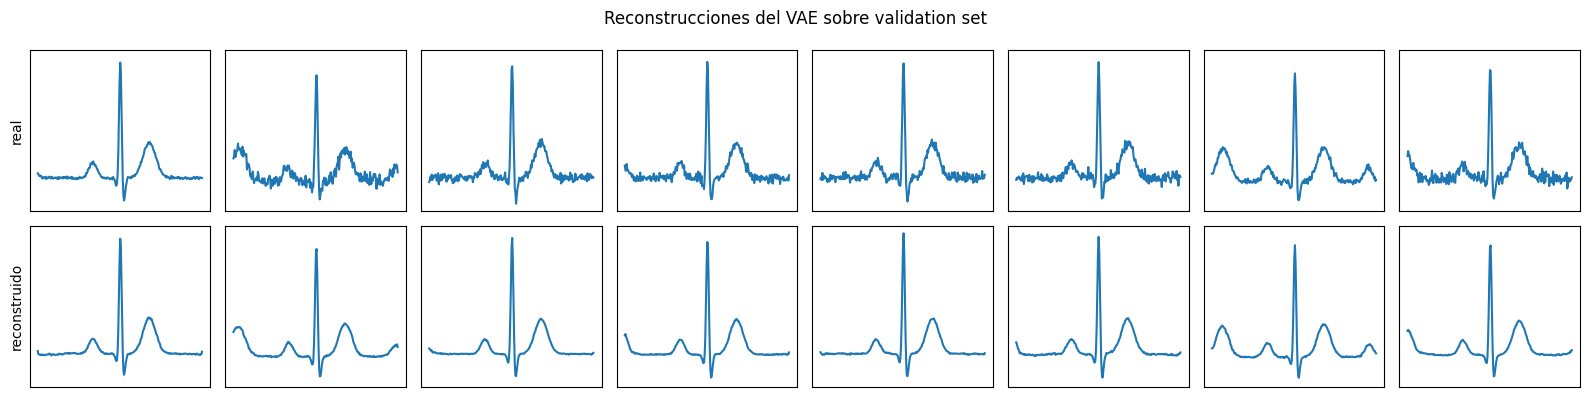

In [34]:
vae.eval()
with torch.no_grad():
    xb = torch.from_numpy(X_val[:8]).float().to(device).unsqueeze(1)
    recon, _, _ = vae(xb)
recon = recon.cpu().numpy().squeeze(1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4), sharex=True, sharey=True)
for ax, x in zip(axes[0], X_val[:8]):
    ax.plot(x); ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel('real')
for ax, x in zip(axes[1], recon):
    ax.plot(x); ax.set_xticks([]); ax.set_yticks([])
axes[1, 0].set_ylabel('reconstruido')
plt.suptitle('Reconstrucciones del VAE sobre validation set')
plt.tight_layout(); plt.show()

### 9.5 Generación — sampling desde el prior

Ahora **el momento clave**: sortear vectores `z ~ N(0, I)` directamente del prior y decodificarlos. Estos son ECGs *que el modelo nunca vio durante entrenamiento*.

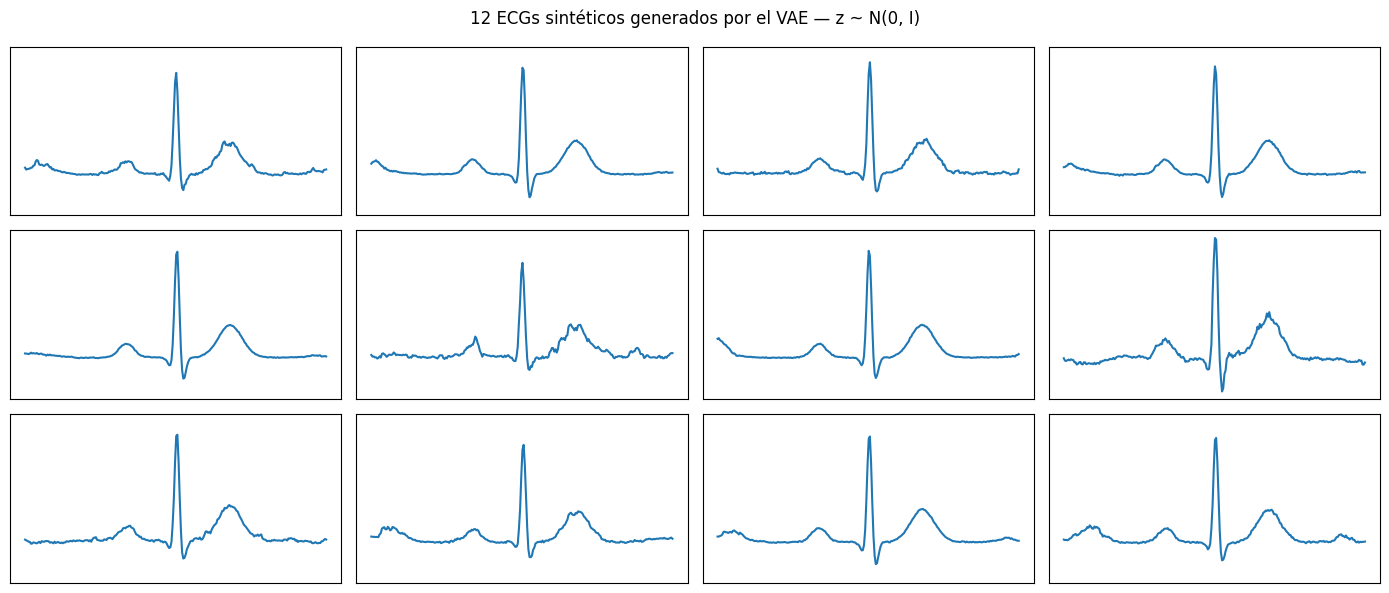

In [35]:
torch.manual_seed(0)
vae.eval()
with torch.no_grad():
    z = torch.randn(12, vae.latent_dim, device=device)
    gen = vae.decode(z).cpu().numpy().squeeze(1)

fig, axes = plt.subplots(3, 4, figsize=(14, 6), sharey=True)
for ax, x in zip(axes.flat, gen):
    ax.plot(x); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('12 ECGs sintéticos generados por el VAE — z ~ N(0, I)')
plt.tight_layout(); plt.show()

Estas señales **no estaban en el dataset** — el VAE las inventó muestreando del espacio latente.

Comparen mentalmente con la **Sección 8.1** (el generador paramétrico): la diferencia es que aquí no le dijimos al modelo dónde poner el pico R ni cuál es la onda T. Lo aprendió a partir de mirar 1800 ejemplos.

### 9.6 Interpolación en el espacio latente

Una propiedad del VAE es que el espacio latente es **continuo y suave**: si interpolamos linealmente entre dos `z` y decodificamos cada punto, deberíamos obtener una transición gradual entre las dos señales.

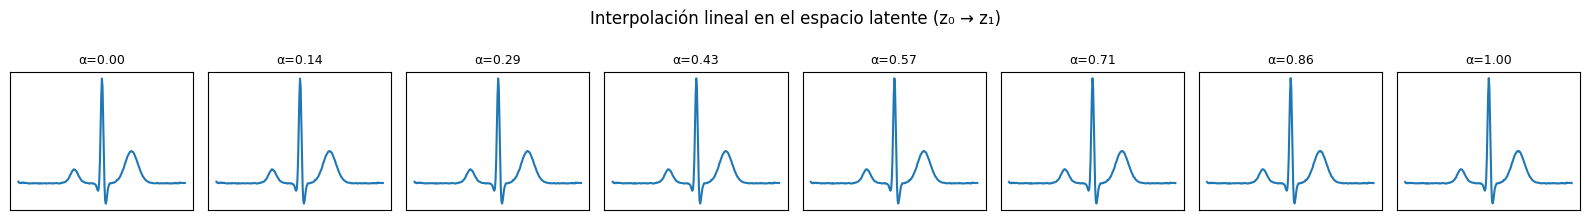

In [36]:
vae.eval()
with torch.no_grad():
    x0 = torch.from_numpy(X_val[0:1]).float().to(device).unsqueeze(1)
    x1 = torch.from_numpy(X_val[5:6]).float().to(device).unsqueeze(1)
    mu0, _ = vae.encode(x0)
    mu1, _ = vae.encode(x1)
    alphas = torch.linspace(0, 1, 8, device=device).unsqueeze(1)
    z_interp = (1 - alphas) * mu0 + alphas * mu1
    decoded = vae.decode(z_interp).cpu().numpy().squeeze(1)

fig, axes = plt.subplots(1, 8, figsize=(16, 2.2), sharey=True)
for i, (ax, x) in enumerate(zip(axes, decoded)):
    ax.plot(x); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'α={i/7:.2f}', fontsize=9)
plt.suptitle('Interpolación lineal en el espacio latente (z₀ → z₁)')
plt.tight_layout(); plt.show()

### 9.7 Evaluar el generador — distribución de RR

Una métrica práctica de *calidad* de un generador biomédico es: **¿las estadísticas de la salida se parecen a las del dataset?**

Tomamos 200 muestras reales y 200 generadas, detectamos sus picos R con `find_peaks`, y comparamos los histogramas de intervalos RR. Si el VAE aprendió bien, las dos distribuciones deberían superponerse.

c:\Python310\lib\site-packages\numpy\lib\_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


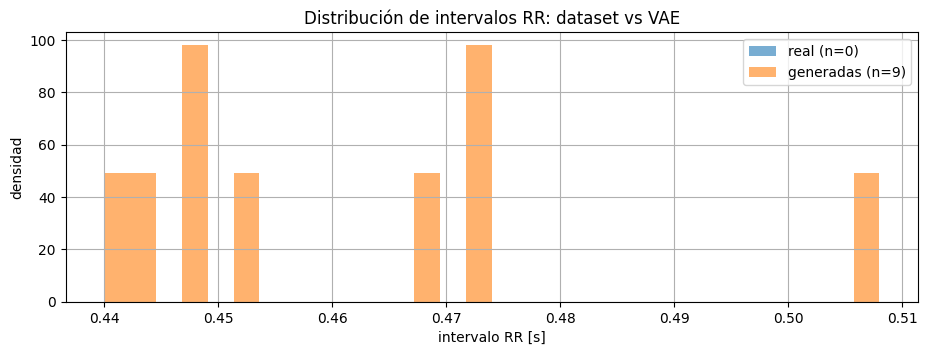

In [37]:
def rr_intervals(seg, fs=FS_GEN, min_dist_s=0.3):
    peaks, _ = sps.find_peaks(seg, height=seg.max() * 0.4, distance=int(min_dist_s * fs))
    return np.diff(peaks) / fs

vae.eval()
with torch.no_grad():
    z = torch.randn(200, vae.latent_dim, device=device)
    gen_batch = vae.decode(z).cpu().numpy().squeeze(1)

rr_real = np.concatenate([rr_intervals(X_val[i]) for i in range(min(200, len(X_val)))])
rr_gen  = np.concatenate([rr_intervals(g) for g in gen_batch])

plt.hist(rr_real, bins=30, alpha=0.6, label=f'real (n={len(rr_real)})', density=True)
plt.hist(rr_gen,  bins=30, alpha=0.6, label=f'generadas (n={len(rr_gen)})', density=True)
plt.xlabel('intervalo RR [s]'); plt.ylabel('densidad'); plt.legend()
plt.title('Distribución de intervalos RR: dataset vs VAE')
plt.show()

### Ejercicio 9.1
Entrená el VAE con **`latent_dim = 2`** y graficá las 1800 muestras de train proyectadas en el plano latente (scatter de `μ(x)`). ¿Se forma alguna estructura? ¿Se separa por frecuencia cardíaca?

*Pista:* podés guardar el `hr` que usaste al generar cada muestra y colorear los puntos por hr.

Epoch 0
Epoch 5
Epoch 10
Epoch 15


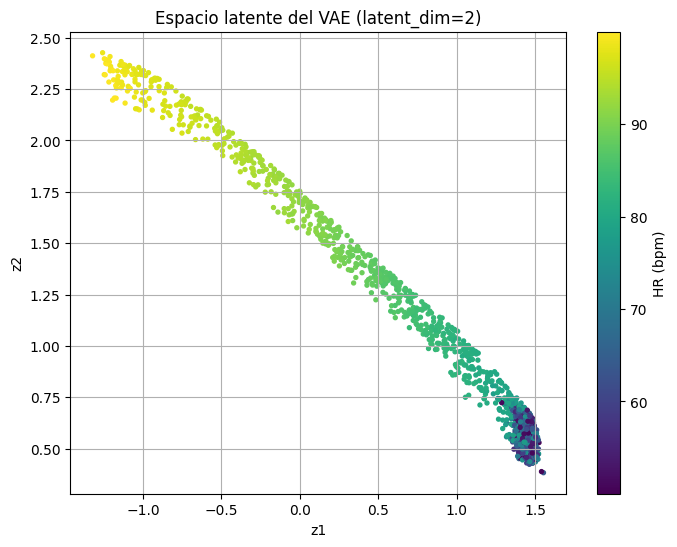

In [42]:
def make_ecg_dataset(n_samples, signal_len=SIGNAL_LEN, fs=FS_GEN, seed=0):

    rng = np.random.default_rng(seed)

    duration_long = 4.0
    half = signal_len // 2

    X = np.zeros((n_samples, signal_len), dtype=np.float32)
    hr_values = np.zeros(n_samples)

    for i in range(n_samples):

        hr = rng.uniform(50,100)
        hr_values[i] = hr

        sigma = rng.uniform(0.005,0.04)

        _, ecg_i = synthetic_ecg(
            duration_long,
            fs,
            hr_bpm=hr
        )

        rr = 60/hr
        r_times = 0.17 + rr*np.arange(
            int(duration_long/rr)
        )

        chosen = r_times[
            np.argmin(
                np.abs(
                    r_times-duration_long/2
                )
            )
        ]

        center = int(chosen*fs)

        start = center-half

        if start < 0 or start+signal_len > len(ecg_i):

            start=max(
                0,
                min(
                    len(ecg_i)-signal_len,
                    start
                )
            )

        seg = ecg_i[start:start+signal_len].copy()

        seg += sigma*rng.standard_normal(signal_len)

        seg = (seg-seg.mean())/(seg.std()+1e-6)

        X[i]=seg

    return X, hr_values


X, hr = make_ecg_dataset(2000)

X_train = X[:1800]
hr_train = hr[:1800]

X_val = X[1800:]


#  loaders
train_loader = to_loader(
    X_train,
    batch_size=64,
    shuffle=True
)

#  VAE con espacio latente de dimensión 2
vae = ECGVAE(
    latent_dim=2
).to(device)

opt = torch.optim.Adam(
    vae.parameters(),
    lr=1e-3
)

n_epochs = 20

for epoch in range(n_epochs):

    vae.train()

    for (xb,) in train_loader:

        xb = xb.to(device)
        xb = xb.unsqueeze(1)

        recon, mu, logvar = vae(xb)

        loss, _, _ = vae_loss(
            recon,
            xb,
            mu,
            logvar
        )

        opt.zero_grad()
        loss.backward()
        opt.step()

    if epoch % 5 == 0:
        print(
            f'Epoch {epoch}'
        )


vae.eval()

with torch.no_grad():

    xb = torch.from_numpy(
        X_train
    ).float().to(device)

    xb = xb.unsqueeze(1)

    mu, _ = vae.encode(xb)

    mu = mu.cpu().numpy()


# Graficar espacio latente
plt.figure(figsize=(8,6))

plt.scatter(
    mu[:,0],
    mu[:,1],
    c=hr_train,
    cmap='viridis',
    s=8
)

plt.xlabel('z1')
plt.ylabel('z2')

plt.colorbar(
    label='HR (bpm)'
)

plt.title(
    'Espacio latente del VAE (latent_dim=2)'
)

plt.show()

#### Respuesta

¿Se forma alguna estructura? → Sí. Las muestras forman una estructura continua y no una distribución aleatoria, indicando que el VAE probablemente organizó las señales según características similares.

¿Se separa por frecuencia cardíaca? → Sí. Se observa un gradiente de colores (las frecuencias cardíacas bajas se agrupan en un extremo y las altas en el otro), mostrando que el VAE aprendió a representar la frecuencia cardíaca dentro del espacio latente.

### Ejercicio 9.2
Probá tres valores de **β** distintos: `β=0.01`, `β=0.5`, `β=10`. Para cada uno, plotteá las reconstrucciones y muestras del prior.

Preguntas a responder en markdown:

- ¿Con cuál β las reconstrucciones se ven mejor?
- ¿Con cuál las muestras del prior se ven mejor?
- ¿Por qué hay una tensión entre las dos cosas? (esto es el famoso *trade-off reconstrucción / regularización* del VAE)


Entrenando con β=0.01


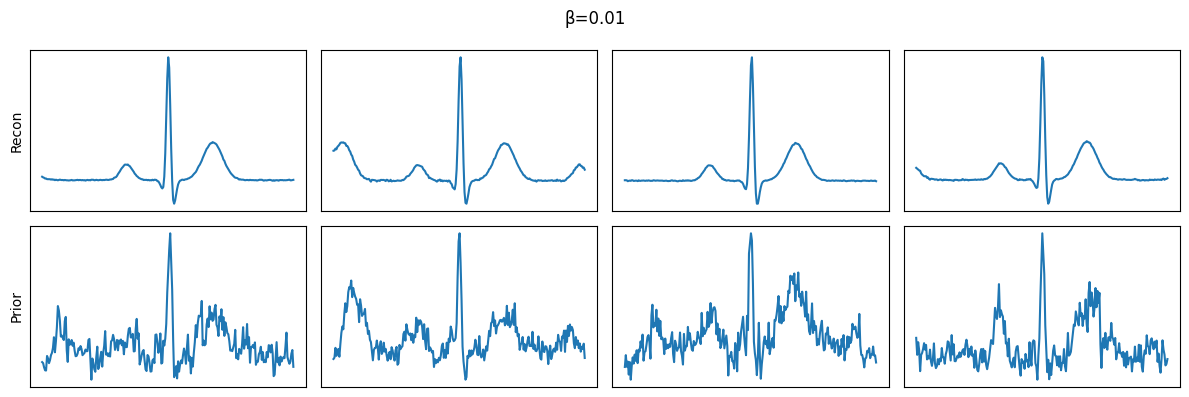


Entrenando con β=0.5


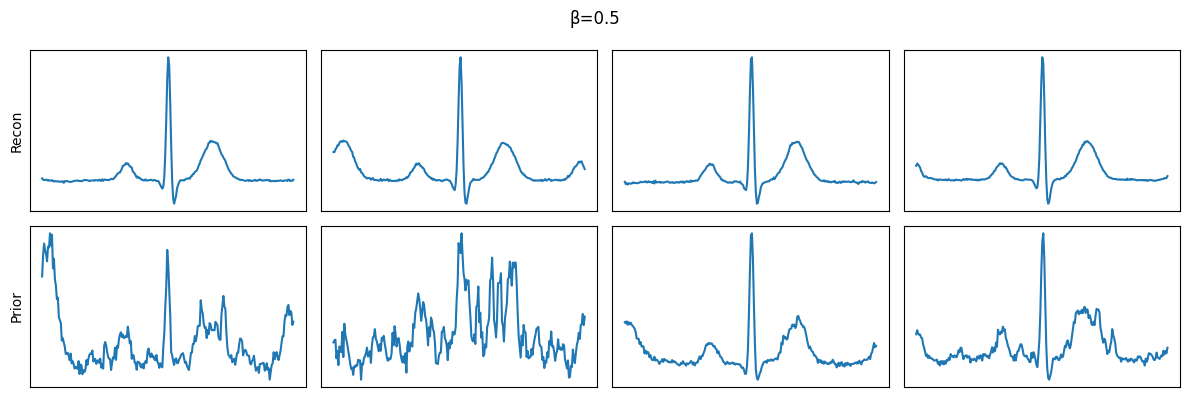


Entrenando con β=10


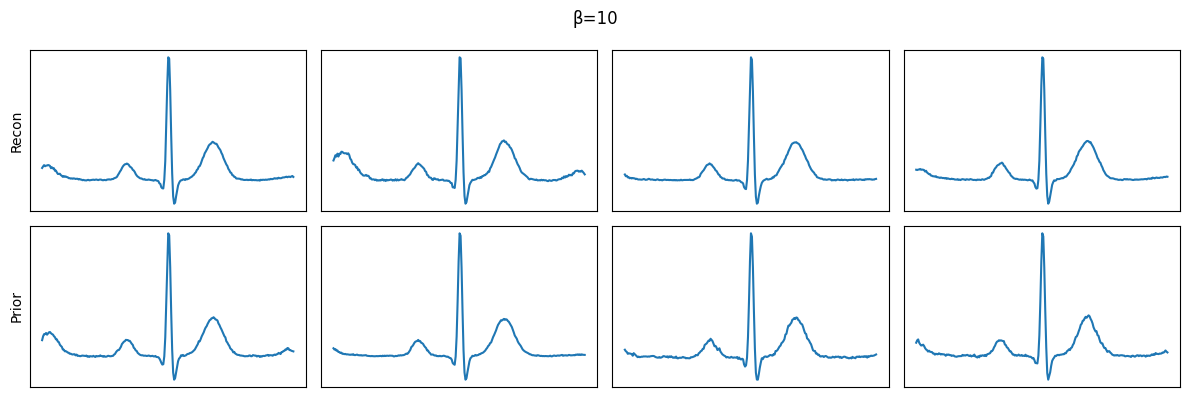

In [44]:
betas = [0.01, 0.5, 10]

for beta in betas:

    print(f'\nEntrenando con β={beta}')

    vae = ECGVAE(latent_dim=8).to(device)

    opt = torch.optim.Adam(
        vae.parameters(),
        lr=1e-3
    )

    for epoch in range(20):

        vae.train()

        for (xb,) in train_loader:

            xb = xb.to(device).unsqueeze(1)

            recon, mu, logvar = vae(xb)

            loss, _, _ = vae_loss(
                recon,
                xb,
                mu,
                logvar,
                beta=beta
            )

            opt.zero_grad()
            loss.backward()
            opt.step()


    # Reconstrucciones
    vae.eval()

    with torch.no_grad():

        xb = torch.from_numpy(
            X_val[:4]
        ).float().to(device)

        xb = xb.unsqueeze(1)

        recon, _, _ = vae(xb)

        recon = recon.cpu().numpy().squeeze()


        # Muestras desde el prior
        z = torch.randn(
            4,
            vae.latent_dim,
            device=device
        )

        gen = vae.decode(
            z
        ).cpu().numpy().squeeze()


    plt.figure(figsize=(12,4))

    for i in range(4):

        plt.subplot(2,4,i+1)
        plt.plot(recon[i])
        plt.xticks([])
        plt.yticks([])

        if i==0:
            plt.ylabel('Recon')


        plt.subplot(2,4,i+5)
        plt.plot(gen[i])
        plt.xticks([])
        plt.yticks([])

        if i==0:
            plt.ylabel('Prior')


    plt.suptitle(
        f'β={beta}'
    )

    plt.tight_layout()
    plt.show()

#### Respuesta 

¿Con cuál β las reconstrucciones se ven mejor? → con β = 0.01. Esto pasa porque el modelo le da mucha importancia a copiar la señal original (reconstruction loss) y poca importancia a ordenar el espacio latente (KL). 

¿Con cuál las muestras del prior se ven mejor? → con β = 10 se observa que las señales generadas son más limpias y tienen una forma más parecida a un ECG real.

¿Por qué hay una tensión entre las dos cosas?
La pérdida del VAE se define como:
Loss = Reconstrucción + β ⋅ KL
Reconstrucción: obliga al modelo a copiar bien la señal de entrada.
KL: obliga a que el espacio latente se parezca a una distribución normal, para poder generar muestras nuevas coherentes.

El parámetro β decide cuál pesa más:
- β chico (en este caso 0.01) → al modelo le importa más copiar exactamente la señal (reconstrucciones buenas, pero espacio latente desordenado, entonces al generar desde el prior aparecen señales raras)
- β grande (en este caso 10) → al modelo le importa más ordenar el espacio latente (las muestras generadas son más consistentes, pero pierde detalles al reconstruir)

### A dónde vamos

Lo que acaban de entrenar es **el modelo generativo más simple posible sobre 1D**. En las próximas clases del módulo:

- **GANs 1D** para señales — adversarial training sobre el mismo dataset.
- **Modelos de difusión 1D** — la idea de Stable Diffusion trasladada al dominio temporal.
- **Modelos condicionados** — generar un ECG dado un *bpm objetivo* o una *clase clínica*.
- **Evaluación rigurosa** — más allá del histograma de RR, qué métricas se usan para decidir si un generador biomédico sirve.

## Cierre y ejercicios adicionales

Cosas para seguir explorando como práctica:

1. **PPG sintético:** modelar una señal PPG (parecida a un seno asimétrico con una segunda joroba dicrótica) y aplicar los mismos pipelines.
2. **`filtfilt` vs `lfilter`:** comparar la salida de los dos. ¿Por qué `filtfilt` no introduce desfasaje? ¿Cuándo *no* podés usarlo (ej. tiempo real)?
3. **Detección sobre ECG sucio:** ¿qué tan robusto es el matched filter al ruido? ¿Y a un cambio en la frecuencia cardíaca?
4. **Data augmentation:** agregar ruido, escalado temporal y pequeñas distorsiones; ploteá las versiones aumentadas. Esto es lo que después usaremos para entrenar modelos.
5. **Datos reales:** si quieren saltar a PhysioNet, instalen `wfdb` y descarguen el dataset `mit-bih-arrhythmia-database` — repliquen el pipeline de filtrado sobre un registro real.

**Para la próxima clase:** mantengan esta notebook a mano — vamos a empezar a usar redes neuronales sobre estas mismas señales.